# Batch Ring-Down Analysis Example

This notebook demonstrates comprehensive batch analysis of multiple ring-down measurement files, including:
- Batch processing of multiple data files
- Q factor analysis from the segmented-demodulation estimator (`q_preference="demod"`)
- Drift, plateau and gating diagnostics per record
- Frequency estimation comparison (NLS vs DFT vs demodulation)
- Consistency analysis across realizations
- CRLB comparison analysis
- Comprehensive visualizations

**Q workflow.** Following the 2026-08-18 Q-estimation investigation, the aggregate Q comes from
the drift-immune incoherent estimator `Q_demod` (`SegmentedDemodEstimator`), selected by
constructing the batch analyzer with `q_preference="demod"`. The coherent estimates (`Q_nls`,
`Q_dft`, `Q_profile`) remain available as diagnostics, but on drifting records the pipeline demotes
them to non-valid (`coherence_gate_fired`, `envelope_mismatch`) and they are skipped by the
aggregate Q. See the README section "Which Q should I trust?" and
[`20260819_EDU_SegmentedDemod_Estimator_Demo.ipynb`](20260819_EDU_SegmentedDemod_Estimator_Demo.ipynb).


In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Apply consistent plotting style
from ringdownanalysis import BatchRingDownAnalyzer, plots

plots.apply_plotting_style()

## Initialize Batch Analyzer

The `BatchRingDownAnalyzer` provides a high-level interface for analyzing multiple ring-down data files in parallel.

`q_preference="demod"` makes the aggregate per-record Q come from the drift-immune
segmented-demodulation estimate, falling back to the (gated) profile/NLS logic only when a record
has no valid demod estimate. The constructor default is still `"profile"` for backward
compatibility; the README migration note explains the upcoming switch.

Measurement files live under `data/` in subdirectories (for example `data/MTS/*.mat`). ODIN Phasemeter exports use `.csv.zip` and are handled in the dedicated ODIN notebooks via `mokutools`; this batch example discovers plain `.csv` and `.mat` files recursively.


In [15]:
# Initialize batch analyzer with the drift-immune Q as the aggregate estimate
batch_analyzer = BatchRingDownAnalyzer(q_preference="demod")

# Resolve repo data directory (files are in subfolders such as data/MTS, not data/ itself)
REPO_ROOT = Path("..").resolve()
data_dir = REPO_ROOT / "data"
print(f"Data directory: {data_dir}")
print(f"Directory exists: {data_dir.is_dir()}")

Data directory: /Users/mdovale/Work-local/RingDownAnalysis/data
Directory exists: True


## Process All Files

Discover loadable `.csv` and `.mat` files recursively under `data/`, then process them with `BatchRingDownAnalyzer`. The analyzer will:
1. Load each file and validate finite time/phase values
2. Estimate tau from the full record, cross-checked against the envelope tau (`tau_est_low_confidence`)
3. Crop data to `max_tau_multiplier * tau_est` (default: 1x tau), never below one envelope tau
4. Run the segmented-demodulation estimator: `Q_demod` with a block-bootstrap CI, the plateau level,
   the frequency drift, and `coherence_ratio` = |drift| × tau
5. Estimate frequency using NLS and DFT methods, and Q coherently — gated to non-valid when the
   drift or envelope-mismatch checks fire
6. Select the trustworthy Q per record (`Q_selected`, with its source and regime)
7. Estimate noise parameters and report a plug-in frequency uncertainty diagnostic for the crop

The batch API can process files in parallel while preserving the configured analyzer settings.
Records here run to several GB, so memory — not CPU — usually limits `n_jobs`.


In [16]:
def discover_ringdown_files(root: Path) -> list[str]:
    """Recursively find .csv and .mat files loadable by RingDownDataLoader."""
    selected: list[str] = []

    for pattern in ("*.csv", "*.mat"):
        for path in sorted(root.rglob(pattern)):
            if path.is_file():
                selected.append(str(path))

    return selected


all_files = discover_ringdown_files(data_dir)
csv_files = [f for f in all_files if f.lower().endswith(".csv")]
mat_files = [f for f in all_files if f.lower().endswith(".mat")]

print(f"Found {len(csv_files)} CSV files and {len(mat_files)} MAT files")
print(f"Total files to process: {len(all_files)}")
if len(all_files) == 0:
    print(
        "\nNo loadable files found. Add .csv or .mat data under data/, "
        "or use an ODIN-specific notebook for .csv.zip Phasemeter exports."
    )

# Process files in parallel through the batch API.
# n_jobs=-1 uses all available CPU cores; set n_jobs=1 for sequential processing.
print(f"\nProcessing {len(all_files)} files with BatchRingDownAnalyzer...")
process_result = batch_analyzer.process_files(all_files, verbose=False, n_jobs=-1)
results = process_result.results

if process_result.has_failures():
    print(f"\nFailed to process {len(process_result.failed_files)} file(s):")
    for filepath, exc in process_result.failed_files:
        print(f"  - {Path(filepath).name}: {exc}")

print(f"\n{'=' * 70}")
print(f"Successfully processed {len(results)} files")
print(f"{'=' * 70}")


def fmt(value, spec=".4g"):
    """Format a possibly-missing estimate."""
    return format(value, spec) if value is not None and np.isfinite(value) else "—"


# Display summary for each file
if len(results) > 0:
    print("\nProcessing Summary:")
    for r in results:
        print(f"  {Path(r['filename']).name}:")
        print(f"    Sampling frequency: {r['fs']:.2f} Hz")
        print(f"    Estimated tau: {r['tau_est']:.2f} s (low confidence: {r['tau_est_low_confidence']})")
        print(f"    Cropped to: {r['T_crop']:.2f} s ({r['N_crop']} samples)")
        print(
            f"    Q_selected: {fmt(r['Q_selected'], '.3e')} "
            f"[source {r['Q_selected_source']}, regime {r['Q_selected_regime']}, "
            f"status {r['Q_selected_status']}]"
        )
        ci = r.get("Q_demod_ci95")
        ci_text = f"[{ci[0]:.3e}, {ci[1]:.3e}]" if ci is not None else "—"
        print(
            f"    Q_demod: {fmt(r['Q_demod'], '.3e')} 95% CI {ci_text} "
            f"({r['Q_demod_status']})"
        )
        drift_mhz = r["Q_demod_drift_hz"] * 1e3 if r["Q_demod_drift_hz"] is not None else None
        print(
            f"    drift: {fmt(drift_mhz, '+.3f')} mHz, coherence_ratio: "
            f"{fmt(r['coherence_ratio'], '.3g')} (gate fired: {r['coherence_gate_fired']})"
        )
        print(
            f"    plateau detected: {r['Q_demod_plateau_detected']} "
            f"(level {fmt(r['Q_demod_plateau_amplitude'], '.3g')})"
        )
        print(
            f"    coherent Q diagnostics: Q_profile {fmt(r['Q_profile'], '.3e')} "
            f"({r['Q_profile_status']}), raw {fmt(r['Q_profile_raw'], '.3e')}; "
            f"Q_nls_raw {fmt(r['Q_nls_raw'], '.3e')}"
        )
        print(f"    NLS frequency: {r['f_nls']:.6f} Hz")
        print(f"    DFT frequency: {r['f_dft']:.6f} Hz")
        print(f"    Difference: {abs(r['f_nls'] - r['f_dft']):.6e} Hz")
        print(f"    Plug-in uncertainty std: {r['plugin_crlb_std_f']:.6e} Hz")
        print(f"    DFT fallback used: {r['dft_used_fallback']}")

Found 2 CSV files and 11 MAT files
Total files to process: 13

Processing 13 files with BatchRingDownAnalyzer...

Successfully processed 13 files

Processing Summary:
  MTS_ringdown_050_laser_out_Test1_20250828_014146_5e-5to1e-5mbar.csv:
    Sampling frequency: 476.87 Hz
    Estimated tau: 800.47 s (low confidence: True)
    Cropped to: 43200.00 s (20599366 samples)
    Q_selected: 3.695e+05 [source demod, regime long_or_drifting, status valid]
    Q_demod: 3.695e+05 95% CI [3.550e+05, 3.891e+05] (valid)
    drift: -0.012 mHz, coherence_ratio: 0.189 (gate fired: False)
    plateau detected: False (level 74.3)
    coherent Q diagnostics: Q_profile — (upper_limit), raw —; Q_nls_raw 3.780e+05
    NLS frequency: 7.200239 Hz
    DFT frequency: 7.200243 Hz
    Difference: 3.564474e-06 Hz
    Plug-in uncertainty std: 4.383629e-07 Hz
    DFT fallback used: False
  MTS_ringdown_050_laser_out_Test5_20250901_224711_1.5e-6mbar.csv:
    Sampling frequency: 119.21 Hz
    Estimated tau: 6812.87 s (lo

## Visualize Sample Time Series

Plot time series for a few sample files to visualize the ring-down signals.


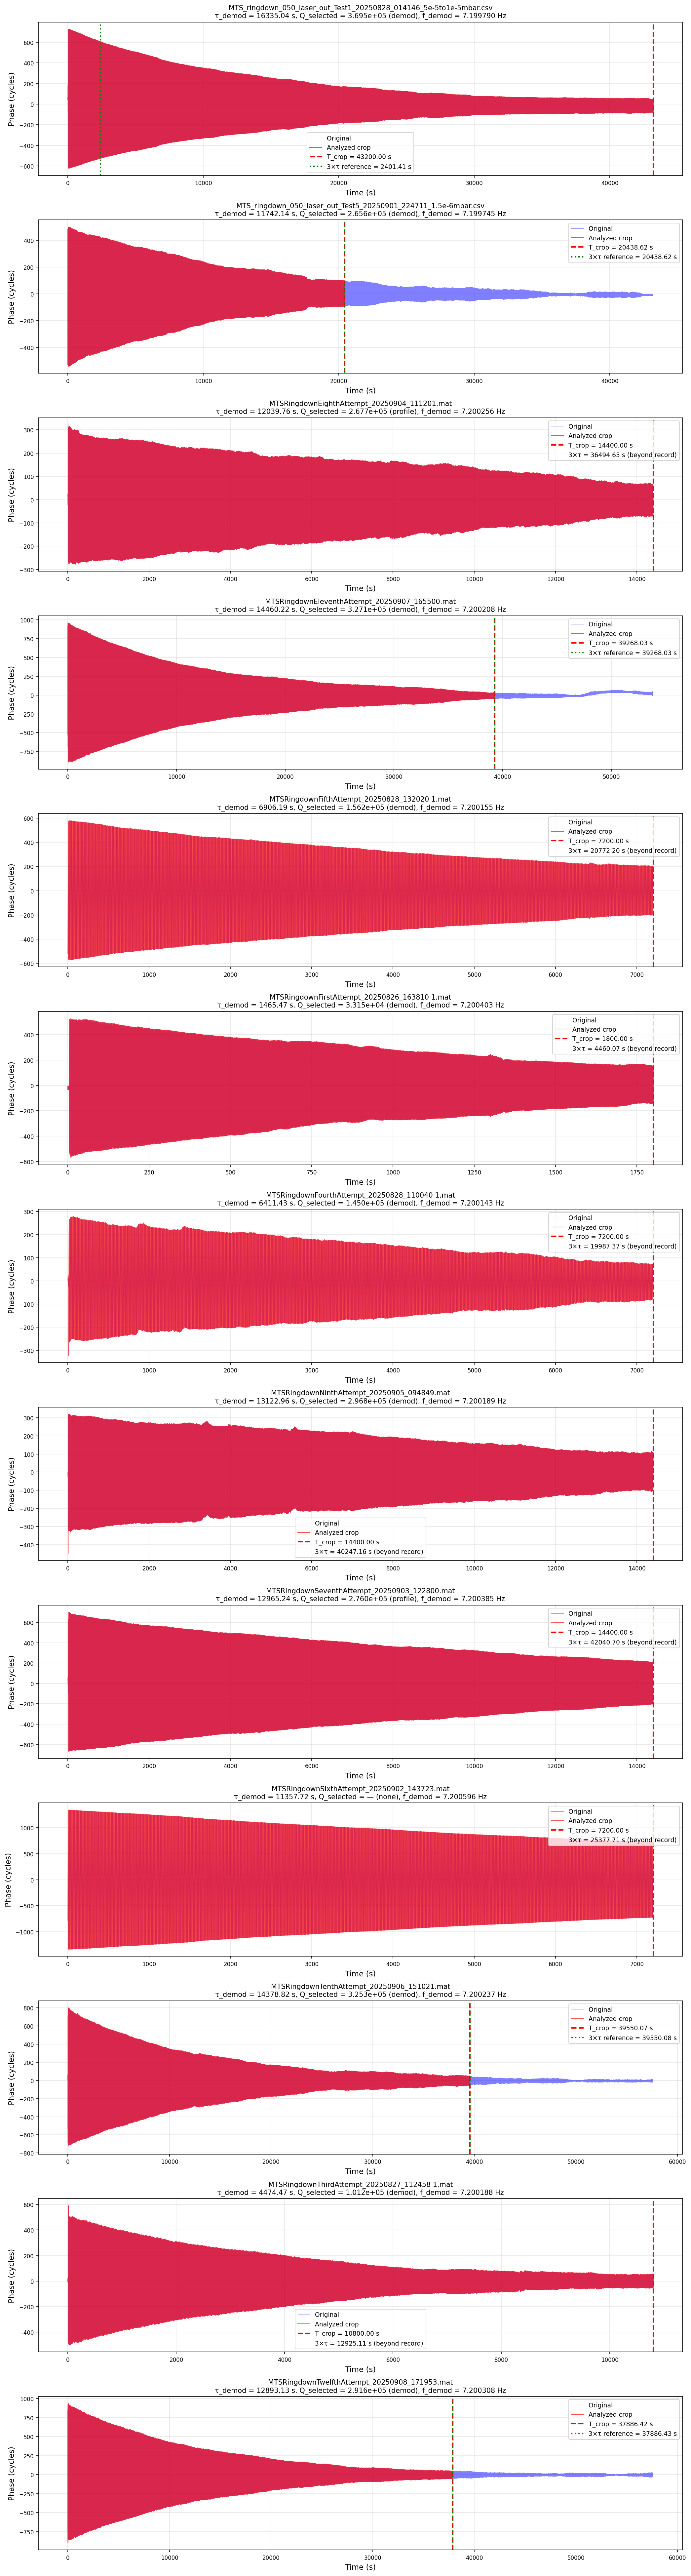

In [17]:
if len(results) > 0:
    n_plots = len(results)

    fig, axes = plt.subplots(n_plots, 1, figsize=(14, 4 * n_plots))

    if n_plots == 1:
        axes = [axes]

    for idx, (ax, r) in enumerate(zip(axes, results[:n_plots])):
        # Downsample for plotting if needed
        step = max(1, len(r["t"]) // 50000)
        step_crop = max(1, len(r["t_crop"]) // 50000)

        # Plot original data
        ax.plot(r["t"][::step], r["data"][::step], "b-", alpha=0.5, label="Original", linewidth=0.5)

        # Plot cropped data
        ax.plot(
            r["t_crop"][::step_crop],
            r["data_cropped"][::step_crop],
            "r-",
            alpha=0.7,
            label="Analyzed crop",
            linewidth=1,
        )

        # Mark the actual crop and a separate 3×tau reference.
        ax.axvline(r["T_crop"], color="r", linestyle="--", linewidth=2, label=f"T_crop = {r['T_crop']:.2f} s")
        tau_3x = 3.0 * r["tau_est"]
        if tau_3x <= r["T"]:
            ax.axvline(tau_3x, color="g", linestyle=":", linewidth=2, label=f"3×τ reference = {tau_3x:.2f} s")
        else:
            ax.plot([], [], " ", label=f"3×τ = {tau_3x:.2f} s (beyond record)")

        ax.set_xlabel("Time (s)", fontsize=11)
        ax.set_ylabel("Phase (cycles)", fontsize=11)
        ax.set_title(
            f"{Path(r['filename']).name}\n"
            f"τ_demod = {fmt(r['tau_demod'], '.2f')} s, "
            f"Q_selected = {fmt(r['Q_selected'], '.3e')} ({r['Q_selected_source']}), "
            f"f_demod = {fmt(r['f_demod'], '.6f')} Hz",
            fontsize=10,
        )
        ax.legend(loc="best", fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No results to plot.")

## Frequency Estimation Comparison

Compare the coherent NLS and DFT frequency estimates with the incoherent segment-average frequency
`f_demod`. Unlike Q, frequency is not destroyed by slow drift — NLS and DFT remain the frequency
estimators of record — but on a drifting resonator any single number is a record average, which is
why the demodulation output also reports the drift explicitly.


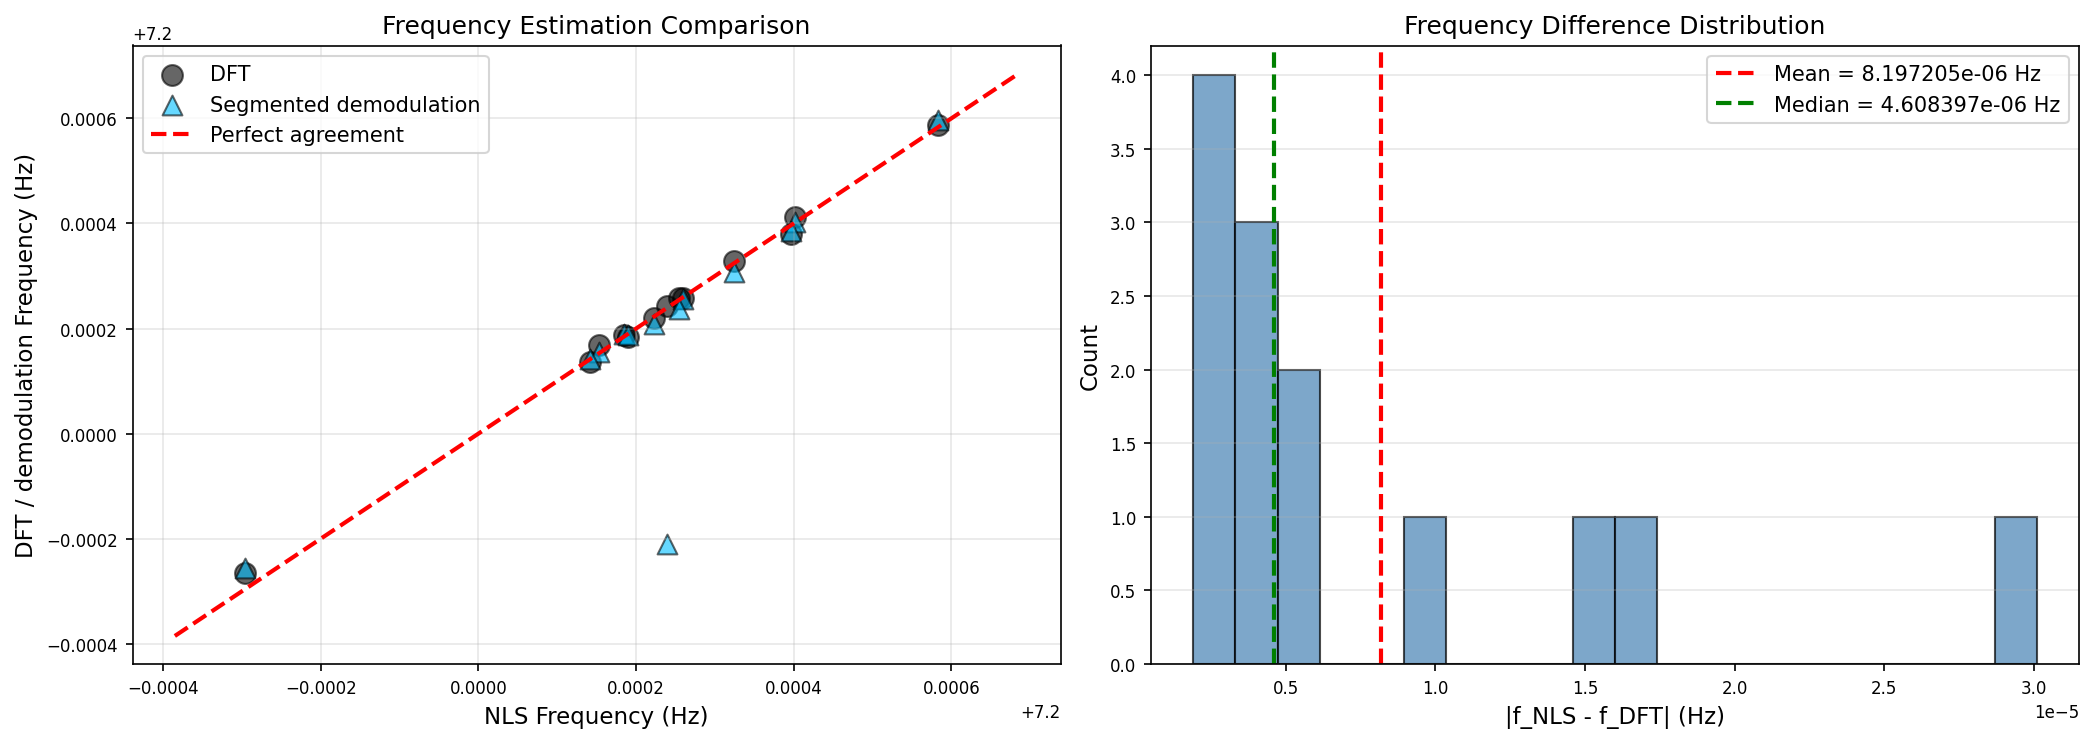

Frequency Statistics:
  NLS mean: 7.200234838 Hz
  NLS std: 1.933155e-04 Hz
  DFT mean: 7.200238201 Hz
  DFT std: 1.873570e-04 Hz
  Demodulation mean: 7.200200216 Hz
  Demodulation std: 2.200703e-04 Hz
  Mean difference: 8.197205e-06 Hz
  Max difference: 3.009518e-05 Hz
  Mean |f_NLS − f_demod|: 4.435715e-05 Hz
  Median measured drift over the decay: +0.0102 mHz


In [18]:
if len(results) > 0:
    f_nls_all = np.array([r["f_nls"] for r in results])
    f_dft_all = np.array([r["f_dft"] for r in results])
    diffs = np.abs(f_nls_all - f_dft_all)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot: NLS vs DFT, with the incoherent demod frequency for reference
    ax = axes[0]
    scatter = ax.scatter(
        f_nls_all, f_dft_all, s=100, alpha=0.6, edgecolors="black", linewidths=1, label="DFT"
    )
    f_demod_all = np.array([r["f_demod"] if r["f_demod"] is not None else np.nan for r in results])
    ax.scatter(
        f_nls_all, f_demod_all, s=90, alpha=0.6, marker="^", color="C2",
        edgecolors="black", linewidths=1, label="Segmented demodulation",
    )
    f_min = min(f_nls_all.min(), f_dft_all.min(), np.nanmin(f_demod_all))
    f_max = max(f_nls_all.max(), f_dft_all.max(), np.nanmax(f_demod_all))
    f_range = f_max - f_min
    ax.plot(
        [f_min - 0.1 * f_range, f_max + 0.1 * f_range],
        [f_min - 0.1 * f_range, f_max + 0.1 * f_range],
        "r--",
        linewidth=2,
        label="Perfect agreement",
    )
    ax.set_xlabel("NLS Frequency (Hz)", fontsize=11)
    ax.set_ylabel("DFT / demodulation Frequency (Hz)", fontsize=11)
    ax.set_title("Frequency Estimation Comparison", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Histogram of differences
    ax = axes[1]
    ax.hist(diffs, bins=20, edgecolor="black", alpha=0.7, color="steelblue")
    ax.axvline(
        np.mean(diffs),
        color="r",
        linestyle="--",
        linewidth=2,
        label=f"Mean = {np.mean(diffs):.6e} Hz",
    )
    ax.axvline(
        np.median(diffs),
        color="g",
        linestyle="--",
        linewidth=2,
        label=f"Median = {np.median(diffs):.6e} Hz",
    )
    ax.set_xlabel("|f_NLS - f_DFT| (Hz)", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title("Frequency Difference Distribution", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()

    print("Frequency Statistics:")
    print(f"  NLS mean: {np.mean(f_nls_all):.9f} Hz")
    print(f"  NLS std: {np.std(f_nls_all):.6e} Hz")
    print(f"  DFT mean: {np.mean(f_dft_all):.9f} Hz")
    print(f"  DFT std: {np.std(f_dft_all):.6e} Hz")
    print(f"  Demodulation mean: {np.nanmean(f_demod_all):.9f} Hz")
    print(f"  Demodulation std: {np.nanstd(f_demod_all):.6e} Hz")
    print(f"  Mean difference: {np.mean(diffs):.6e} Hz")
    print(f"  Max difference: {np.max(diffs):.6e} Hz")
    print(f"  Mean |f_NLS − f_demod|: {np.nanmean(np.abs(f_nls_all - f_demod_all)):.6e} Hz")
    drift_mhz = np.array(
        [(r["Q_demod_drift_hz"] or np.nan) * 1e3 for r in results], dtype=float
    )
    print(f"  Median measured drift over the decay: {np.nanmedian(drift_mhz):+.4f} mHz")
else:
    print("No results to plot.")

## Q Factor Analysis

Calculate and visualize Q factors for all measurements. `calculate_q_factors()` follows the
analyzer's `q_preference="demod"`, so each record contributes its valid segmented-demodulation Q;
records whose preferred estimator has no valid finite Q (for example plateau-dominated windows) are
skipped rather than filled in from a coherent fit.


Aggregate Q source: q_preference = 'demod'
Records contributing a valid Q: 12 of 13

Q Factor Statistics:
  Mean Q: 2.40e+05
  Std Q: 1.00e+05
  Min Q: 3.32e+04
  Max Q: 3.69e+05
  Range: 3.36e+05

Records with no valid Q (skipped):
  MTSRingdownSixthAttempt_20250902_143723.mat: Q_demod_status=warning (demod_decay_window_shorter_than_tau), Q_selected_status=invalid

  Q_demod mean (all finite): 2.41e+05
  Q_profile_raw mean (diagnostic only): 2.14e+05
  Q_envelope mean (diagnostic only): 2.40e+05
  Records where the drift gate demoted coherent estimates: 8 of 13


/var/folders/z2/0sr40kf12437n7qv4v0qb7gm0000gn/T/ipykernel_40265/86432760.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([q_factors], labels=["Q Factor"], patch_artist=True, widths=0.6)


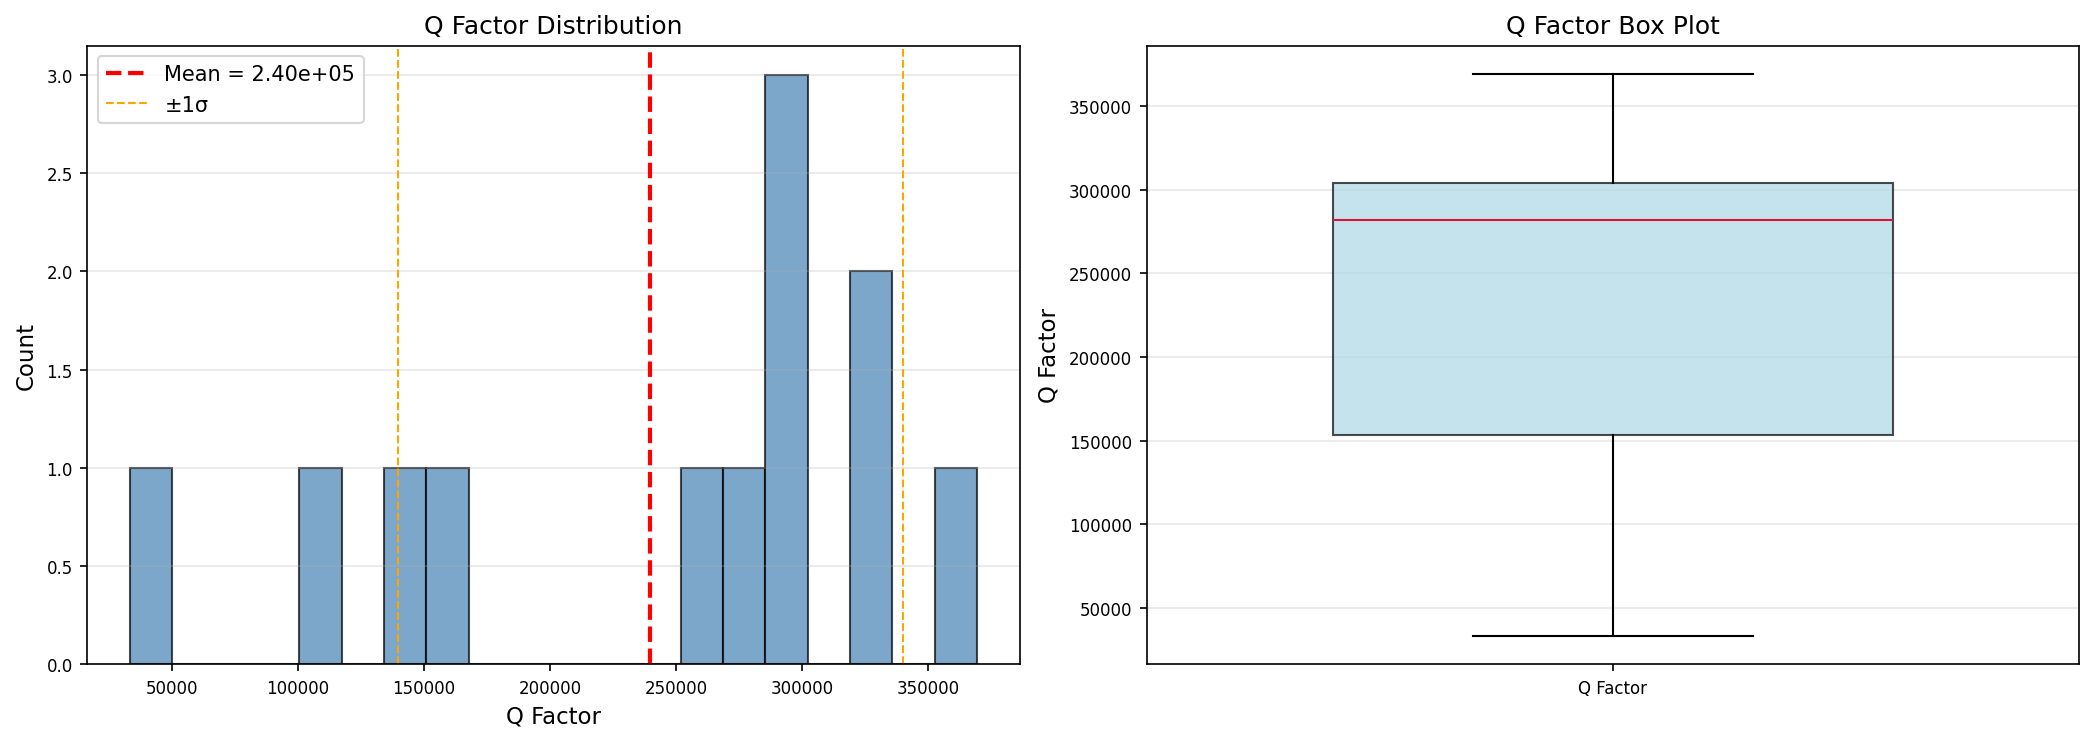

In [19]:
# calculate_q_factors() populates r["Q"] using the analyzer's q_preference ("demod" here)
if len(results) == 0:
    print("No results available. Run the processing cell above first.")
else:
    q_factors = batch_analyzer.calculate_q_factors()
    q_stats = batch_analyzer.get_q_factor_statistics()

    print(f"Aggregate Q source: q_preference = {batch_analyzer.q_preference!r}")
    print(f"Records contributing a valid Q: {len(q_factors)} of {len(results)}")
    print("\nQ Factor Statistics:")
    print(f"  Mean Q: {q_stats['mean']:.2e}")
    print(f"  Std Q: {q_stats['std']:.2e}")
    print(f"  Min Q: {q_stats['min']:.2e}")
    print(f"  Max Q: {q_stats['max']:.2e}")
    print(f"  Range: {q_stats['range']:.2e}")

    skipped = [r for r in results if r.get("Q") is None]
    if skipped:
        print("\nRecords with no valid Q (skipped):")
        for r in skipped:
            print(
                f"  {Path(r['filename']).name}: Q_demod_status={r['Q_demod_status']} "
                f"({', '.join(r['Q_demod_reasons']) or 'no reasons'}), "
                f"Q_selected_status={r['Q_selected_status']}"
            )

    # Compare against the coherent diagnostics: gated Q values are not aggregated
    q_demod_all = [r["Q_demod"] for r in results if r["Q_demod"] is not None]
    q_profile_raw_all = [r["Q_profile_raw"] for r in results if r["Q_profile_raw"] is not None]
    q_envelope_all = [r["Q_envelope"] for r in results if r["Q_envelope"] is not None]
    if q_demod_all:
        print(f"\n  Q_demod mean (all finite): {np.mean(q_demod_all):.2e}")
    if q_profile_raw_all:
        print(f"  Q_profile_raw mean (diagnostic only): {np.mean(q_profile_raw_all):.2e}")
    if q_envelope_all:
        print(f"  Q_envelope mean (diagnostic only): {np.mean(q_envelope_all):.2e}")
    n_gated = sum(1 for r in results if r["coherence_gate_fired"])
    print(f"  Records where the drift gate demoted coherent estimates: {n_gated} of {len(results)}")

    # Visualize Q factors
    if len(q_factors) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Histogram
        ax = axes[0]
        ax.hist(q_factors, bins=20, edgecolor="black", alpha=0.7, color="steelblue")
        ax.axvline(
            q_stats["mean"],
            color="r",
            linestyle="--",
            linewidth=2,
            label=f"Mean = {q_stats['mean']:.2e}",
        )
        ax.axvline(
            q_stats["mean"] + q_stats["std"], color="orange", linestyle="--", linewidth=1, label="±1σ"
        )
        ax.axvline(q_stats["mean"] - q_stats["std"], color="orange", linestyle="--", linewidth=1)
        ax.set_xlabel("Q Factor", fontsize=11)
        ax.set_ylabel("Count", fontsize=11)
        ax.set_title("Q Factor Distribution", fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, axis="y")

        # Box plot
        ax = axes[1]
        bp = ax.boxplot([q_factors], labels=["Q Factor"], patch_artist=True, widths=0.6)
        bp["boxes"][0].set_facecolor("lightblue")
        bp["boxes"][0].set_alpha(0.7)
        ax.set_ylabel("Q Factor", fontsize=11)
        ax.set_title("Q Factor Box Plot", fontsize=12)
        ax.grid(True, alpha=0.3, axis="y")

        plt.tight_layout()
        plt.show()

## Consistency Analysis

Analyze consistency of frequency estimates across all realizations.


Consistency Analysis Summary:
  Number of realizations: 13
  Number of pairwise comparisons: 78

NLS Method:
  Mean frequency: 7.200234838 Hz
  Std across realizations: 1.933155e-04 Hz
  Coefficient of variation: 2.68e-05
  Range: [7.199703994, 7.200582730] Hz
  Span: 8.787354e-04 Hz

DFT Method:
  Mean frequency: 7.200238201 Hz
  Std across realizations: 1.873570e-04 Hz
  Coefficient of variation: 2.60e-05
  Range: [7.199734090, 7.200587600] Hz
  Span: 8.535105e-04 Hz


/var/folders/z2/0sr40kf12437n7qv4v0qb7gm0000gn/T/ipykernel_40265/1869765830.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([f_nls_all, f_dft_all], labels=["NLS", "DFT"], patch_artist=True, widths=0.6)


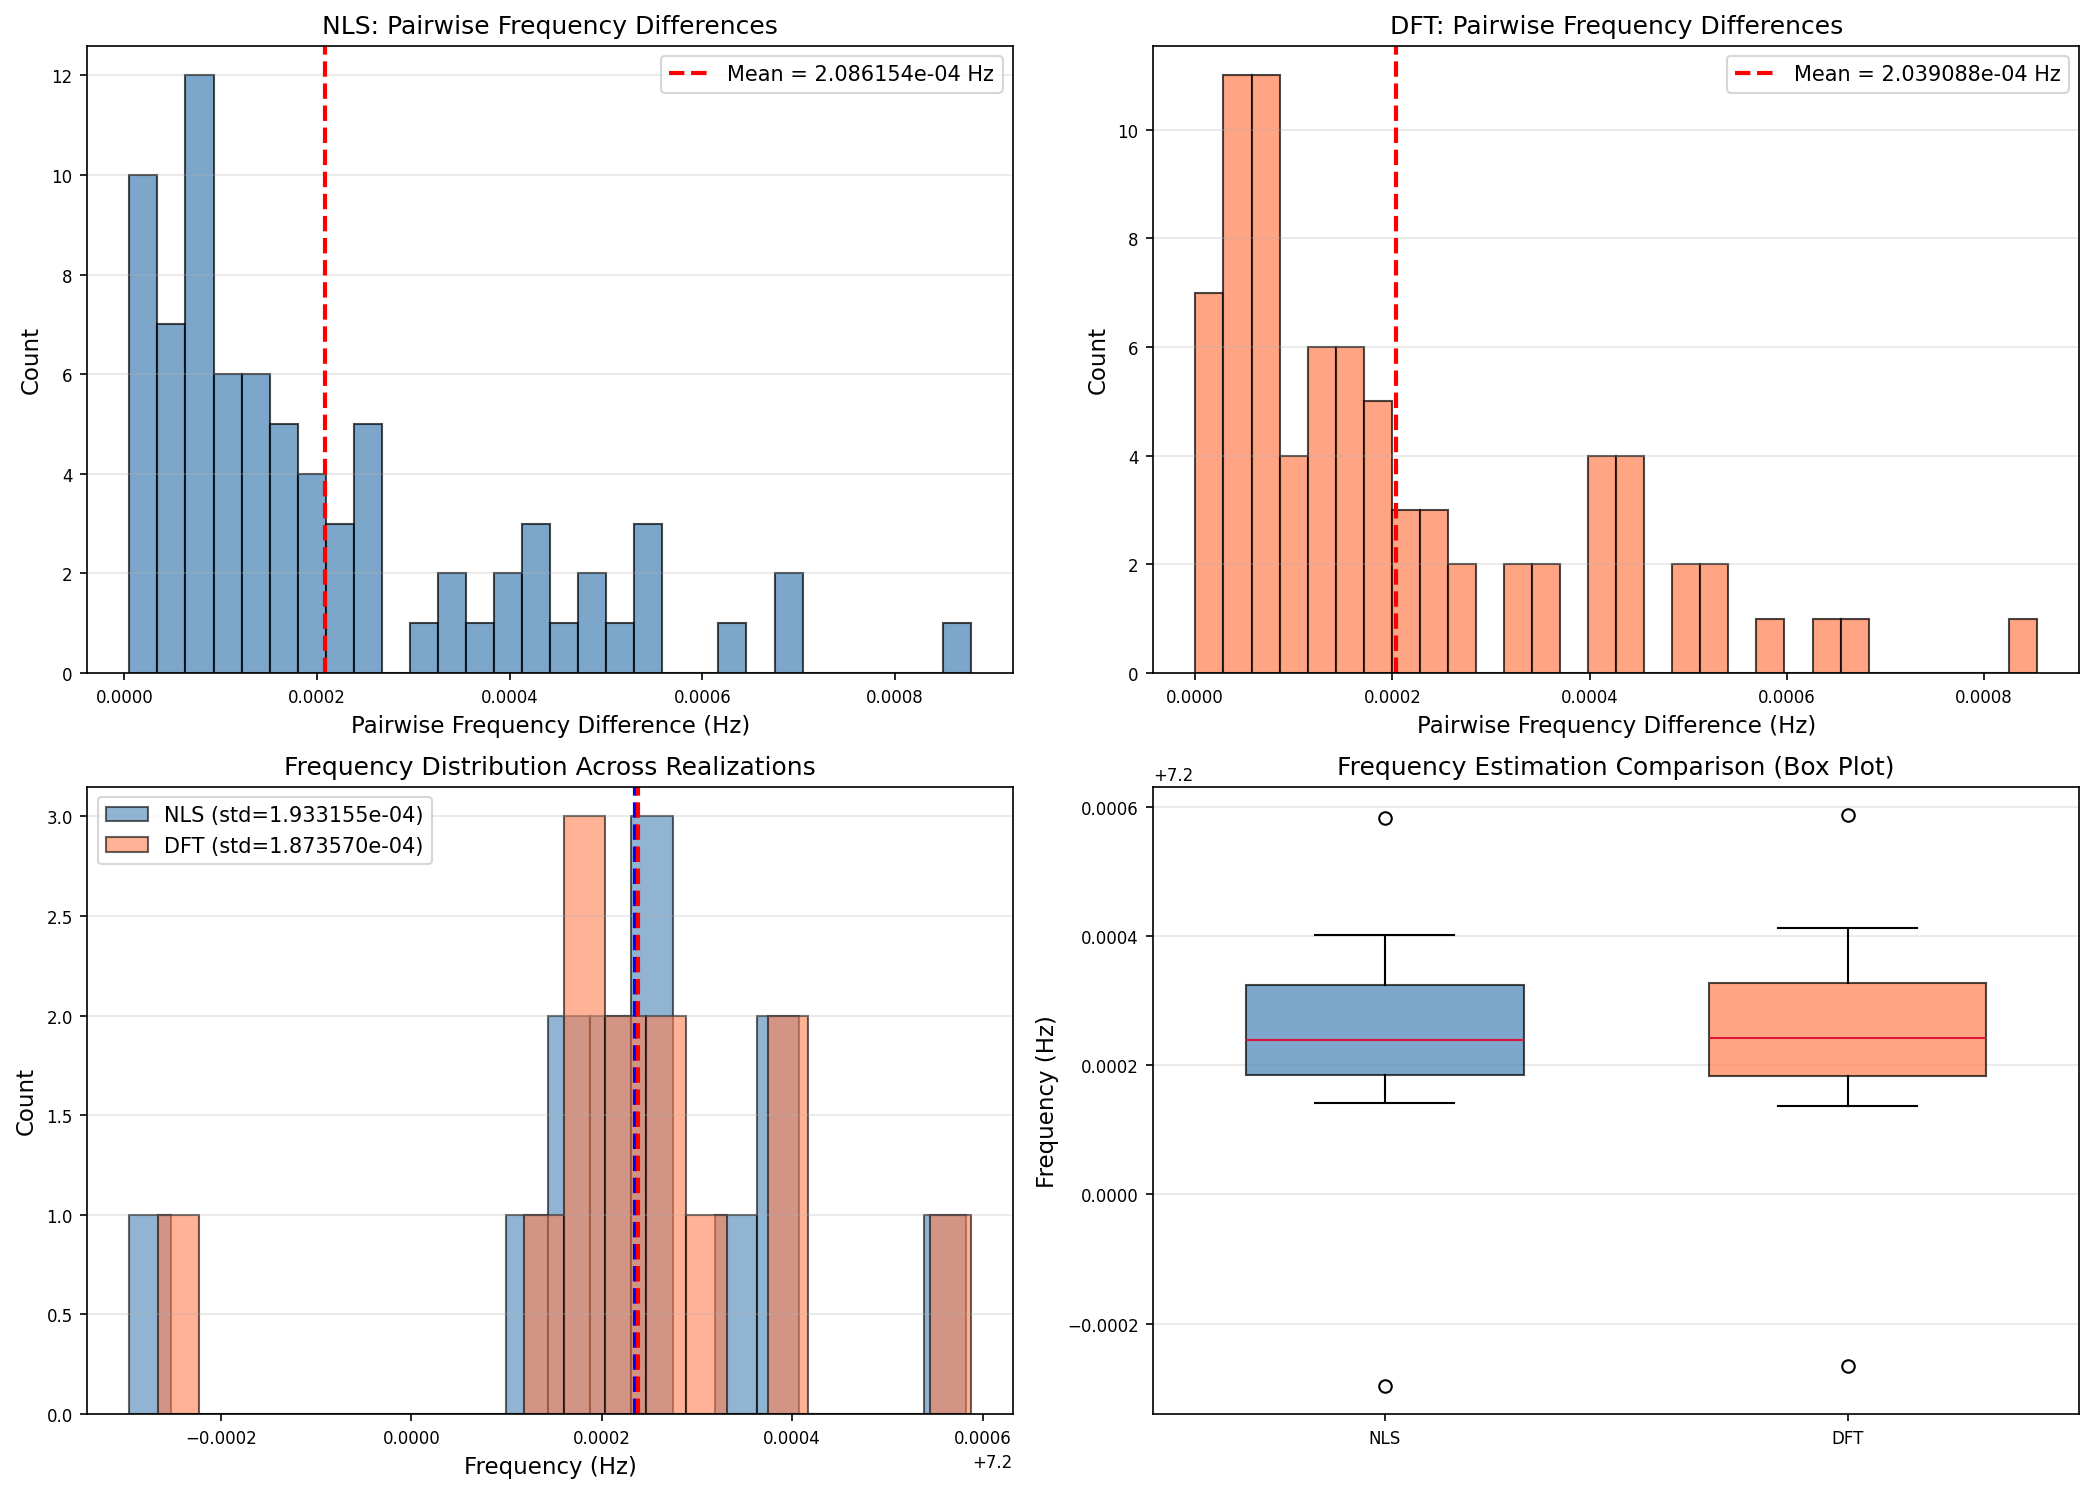

In [20]:
# Perform consistency analysis
consistency = batch_analyzer.consistency_analysis()

print("Consistency Analysis Summary:")
print(f"  Number of realizations: {consistency['n_realizations']}")
print(f"  Number of pairwise comparisons: {consistency['n_pairwise_comparisons']}")
print("\nNLS Method:")
print(f"  Mean frequency: {consistency['nls_mean']:.9f} Hz")
print(f"  Std across realizations: {consistency['nls_std_across_realizations']:.6e} Hz")
print(f"  Coefficient of variation: {consistency['nls_cv']:.2e}")
print(f"  Range: [{consistency['nls_range'][0]:.9f}, {consistency['nls_range'][1]:.9f}] Hz")
print(f"  Span: {consistency['nls_span']:.6e} Hz")
print("\nDFT Method:")
print(f"  Mean frequency: {consistency['dft_mean']:.9f} Hz")
print(f"  Std across realizations: {consistency['dft_std_across_realizations']:.6e} Hz")
print(f"  Coefficient of variation: {consistency['dft_cv']:.2e}")
print(f"  Range: [{consistency['dft_range'][0]:.9f}, {consistency['dft_range'][1]:.9f}] Hz")
print(f"  Span: {consistency['dft_span']:.6e} Hz")

# Visualize consistency
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Pairwise differences histogram - NLS
ax = axes[0, 0]
nls_diffs = consistency["nls_pairwise_diffs"]
ax.hist(nls_diffs, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
ax.axvline(
    consistency["nls_statistics"]["mean"],
    color="r",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {consistency['nls_statistics']['mean']:.6e} Hz",
)
ax.set_xlabel("Pairwise Frequency Difference (Hz)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("NLS: Pairwise Frequency Differences", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

# Pairwise differences histogram - DFT
ax = axes[0, 1]
dft_diffs = consistency["dft_pairwise_diffs"]
ax.hist(dft_diffs, bins=30, edgecolor="black", alpha=0.7, color="coral")
ax.axvline(
    consistency["dft_statistics"]["mean"],
    color="r",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {consistency['dft_statistics']['mean']:.6e} Hz",
)
ax.set_xlabel("Pairwise Frequency Difference (Hz)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("DFT: Pairwise Frequency Differences", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

# Frequency distribution across realizations
ax = axes[1, 0]
f_nls_all = np.array([r["f_nls"] for r in results])
f_dft_all = np.array([r["f_dft"] for r in results])
ax.hist(
    f_nls_all,
    bins=20,
    alpha=0.6,
    label=f"NLS (std={consistency['nls_std_across_realizations']:.6e})",
    edgecolor="black",
    color="steelblue",
)
ax.hist(
    f_dft_all,
    bins=20,
    alpha=0.6,
    label=f"DFT (std={consistency['dft_std_across_realizations']:.6e})",
    edgecolor="black",
    color="coral",
)
ax.axvline(consistency["nls_mean"], color="blue", linestyle="--", linewidth=2)
ax.axvline(consistency["dft_mean"], color="red", linestyle="--", linewidth=2)
ax.set_xlabel("Frequency (Hz)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Frequency Distribution Across Realizations", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

# Box plot comparison
ax = axes[1, 1]
bp = ax.boxplot([f_nls_all, f_dft_all], labels=["NLS", "DFT"], patch_artist=True, widths=0.6)
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][0].set_alpha(0.7)
bp["boxes"][1].set_facecolor("coral")
bp["boxes"][1].set_alpha(0.7)
ax.set_ylabel("Frequency (Hz)", fontsize=11)
ax.set_title("Frequency Estimation Comparison (Box Plot)", fontsize=12)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## Plug-in Uncertainty Comparison

Compare frequency estimation differences with the analyzer's plug-in uncertainty diagnostic. These ratios are useful heuristics, not formal CRLB consistency tests, because the bound is computed from fitted/cropped data and the NLS/DFT estimates are correlated.


Plug-in Uncertainty Statistics:
  Mean plugin std: 4.225646e-08 Hz
  Min plugin std: 2.723353e-09 Hz
  Max plugin std: 4.383629e-07 Hz

Heuristic Ratio Statistics (|Δf| / plugin bound):
  Mean ratio: 1181.5761
  Median ratio: 845.1112
  Max ratio: 3327.7189
  Min ratio: 8.1313


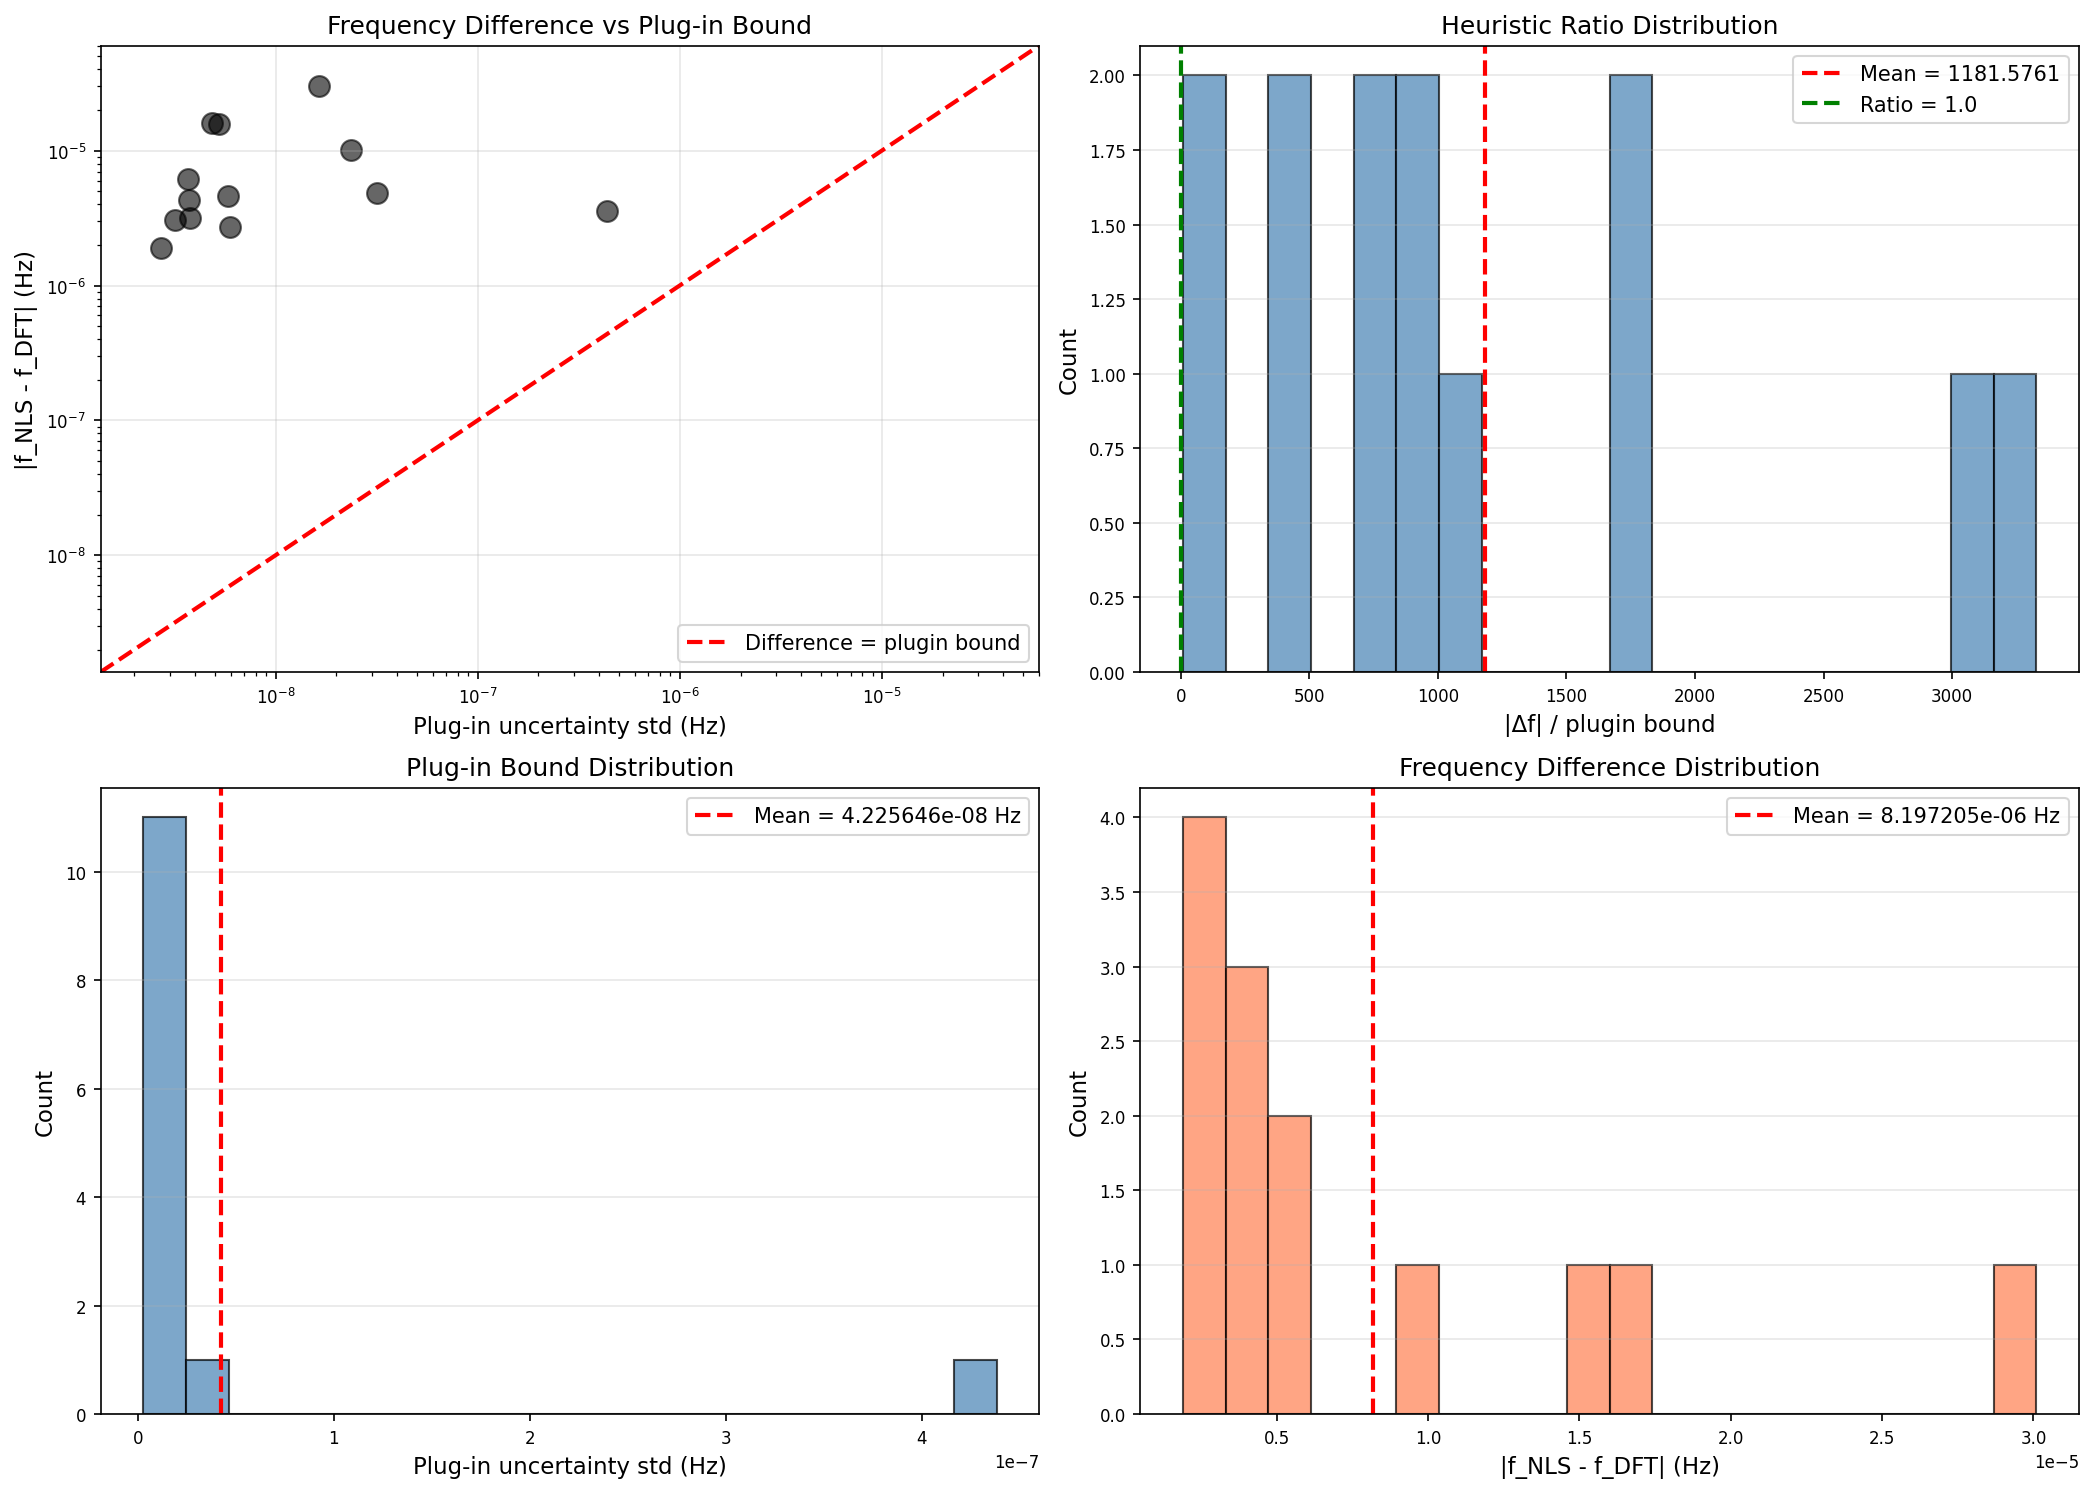

In [21]:
# Perform plug-in uncertainty comparison analysis
crlb_analysis = batch_analyzer.crlb_comparison_analysis()

print("Plug-in Uncertainty Statistics:")
print(f"  Mean plugin std: {crlb_analysis['crlb_statistics']['mean']:.6e} Hz")
print(f"  Min plugin std: {crlb_analysis['crlb_statistics']['min']:.6e} Hz")
print(f"  Max plugin std: {crlb_analysis['crlb_statistics']['max']:.6e} Hz")

if len(crlb_analysis["valid_ratios"]) > 0:
    print("\nHeuristic Ratio Statistics (|Δf| / plugin bound):")
    print(f"  Mean ratio: {crlb_analysis['ratio_statistics']['mean']:.4f}")
    print(f"  Median ratio: {crlb_analysis['ratio_statistics']['median']:.4f}")
    print(f"  Max ratio: {crlb_analysis['ratio_statistics']['max']:.4f}")
    print(f"  Min ratio: {crlb_analysis['ratio_statistics']['min']:.4f}")

# Visualize plug-in uncertainty comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Frequency differences vs plug-in bound
ax = axes[0, 0]
freq_diffs = crlb_analysis["frequency_diffs"]
plugin_stds = crlb_analysis["plugin_crlb_stds"]
ax.scatter(plugin_stds, freq_diffs, s=100, alpha=0.6, edgecolors="black")
# Plot 1:1 reference line
min_val = min(plugin_stds.min(), freq_diffs.min())
max_val = max(plugin_stds.max(), freq_diffs.max())
# Use a small margin for log scale
min_plot = min_val * 0.5
max_plot = max_val * 2.0
ax.loglog([min_plot, max_plot], [min_plot, max_plot], "r--", linewidth=2, label="Difference = plugin bound")
# Set xlim and ylim to same range so 1:1 line is fully visible
ax.set_xlim([min_plot, max_plot])
ax.set_ylim([min_plot, max_plot])
ax.set_xlabel("Plug-in uncertainty std (Hz)", fontsize=11)
ax.set_ylabel("|f_NLS - f_DFT| (Hz)", fontsize=11)
ax.set_title("Frequency Difference vs Plug-in Bound", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Ratio histogram
ax = axes[0, 1]
valid_ratios = crlb_analysis["valid_ratios"]
if len(valid_ratios) > 0:
    ax.hist(valid_ratios, bins=20, edgecolor="black", alpha=0.7, color="steelblue")
    ax.axvline(
        crlb_analysis["ratio_statistics"]["mean"],
        color="r",
        linestyle="--",
        linewidth=2,
        label=f"Mean = {crlb_analysis['ratio_statistics']['mean']:.4f}",
    )
    ax.axvline(1.0, color="g", linestyle="--", linewidth=2, label="Ratio = 1.0")
    ax.set_xlabel("|Δf| / plugin bound", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title("Heuristic Ratio Distribution", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis="y")
else:
    ax.text(
        0.5, 0.5, "No valid ratios", ha="center", va="center", transform=ax.transAxes, fontsize=12
    )

# Plug-in bound distribution
ax = axes[1, 0]
ax.hist(plugin_stds, bins=20, edgecolor="black", alpha=0.7, color="steelblue")
ax.axvline(
    crlb_analysis["crlb_statistics"]["mean"],
    color="r",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {crlb_analysis['crlb_statistics']['mean']:.6e} Hz",
)
ax.set_xlabel("Plug-in uncertainty std (Hz)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Plug-in Bound Distribution", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

# Frequency differences distribution
ax = axes[1, 1]
ax.hist(freq_diffs, bins=20, edgecolor="black", alpha=0.7, color="coral")
ax.axvline(
    np.mean(freq_diffs),
    color="r",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {np.mean(freq_diffs):.6e} Hz",
)
ax.set_xlabel("|f_NLS - f_DFT| (Hz)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Frequency Difference Distribution", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## Summary Tables

Generate comprehensive summary tables of all analysis results.


In [22]:
# Generate display-formatted summary table
summary = batch_analyzer.get_formatted_summary_table()
df_summary = pd.DataFrame(summary["data"])

print("Summary of Frequency Estimation Results:")
print("=" * 120)
print(df_summary.to_string(index=False))

Summary of Frequency Estimation Results:
                                                           Filename Type  N (samples)  N_crop (samples)    T (s) T_crop (s) fs (Hz) tau_seed (s)                              tau_seed_method tau_est (s)  tau_est_fit_success tau_nls (s) tau_dft (s)  tau_est_low_confidence  tau_nls_at_lower_bound  tau_nls_at_upper_bound  tau_dft_at_lower_bound  tau_dft_at_upper_bound f_NLS (Hz) f_DFT (Hz) |f_NLS - f_DFT| (Hz) Q_pre_crop    Q_NLS Q_NLS_raw  Q_NLS_valid Q_NLS_status                                                                     Q_NLS_reasons    Q_DFT Q_DFT_raw  Q_DFT_valid Q_DFT_status                                                                     Q_DFT_reasons Q_profile Q_profile_raw  Q_profile_valid Q_profile_status    Q_profile_reasons                           Q_profile_ci95 Q_profile_lower_limit_95 Q_profile_upper_limit_95 tau_profile (s) f_profile (Hz)  Q_demod  Q_demod_valid Q_demod_status                     Q_demod_reasons         

In [23]:
# Generate display-formatted consistency table
consistency_table = batch_analyzer.get_formatted_consistency_table()
df_consistency = pd.DataFrame(consistency_table["data"])

print("\nFrequency Estimates and Deviations from Mean:")
print("=" * 120)
print(df_consistency.to_string(index=False))


Frequency Estimates and Deviations from Mean:
 Index                                 Filename  f_NLS (Hz)  f_DFT (Hz) Deviation from NLS mean (Hz) Deviation from DFT mean (Hz) Plugin bound std (Hz)  NLS success  DFT success  DFT used fallback
     0 MTS_ringdown_050_laser_out_Test1_2025082 7.200239215 7.200242779                 4.376622e-06                 4.578421e-06          4.383629e-07         True         True              False
     1 MTS_ringdown_050_laser_out_Test5_2025090 7.199703994 7.199734090                -5.308435e-04                -5.041110e-04          1.643572e-08         True         True              False
     2 MTSRingdownEighthAttempt_20250904_111201 7.200259322 7.200257412                 2.448406e-05                 1.921174e-05          2.723353e-09         True         True              False
     3 MTSRingdownEleventhAttempt_20250907_1655 7.200223047 7.200220354                -1.179089e-05                -1.784621e-05          5.919467e-09         True 

## Summary Statistics Overview

Display key statistics in a compact format.


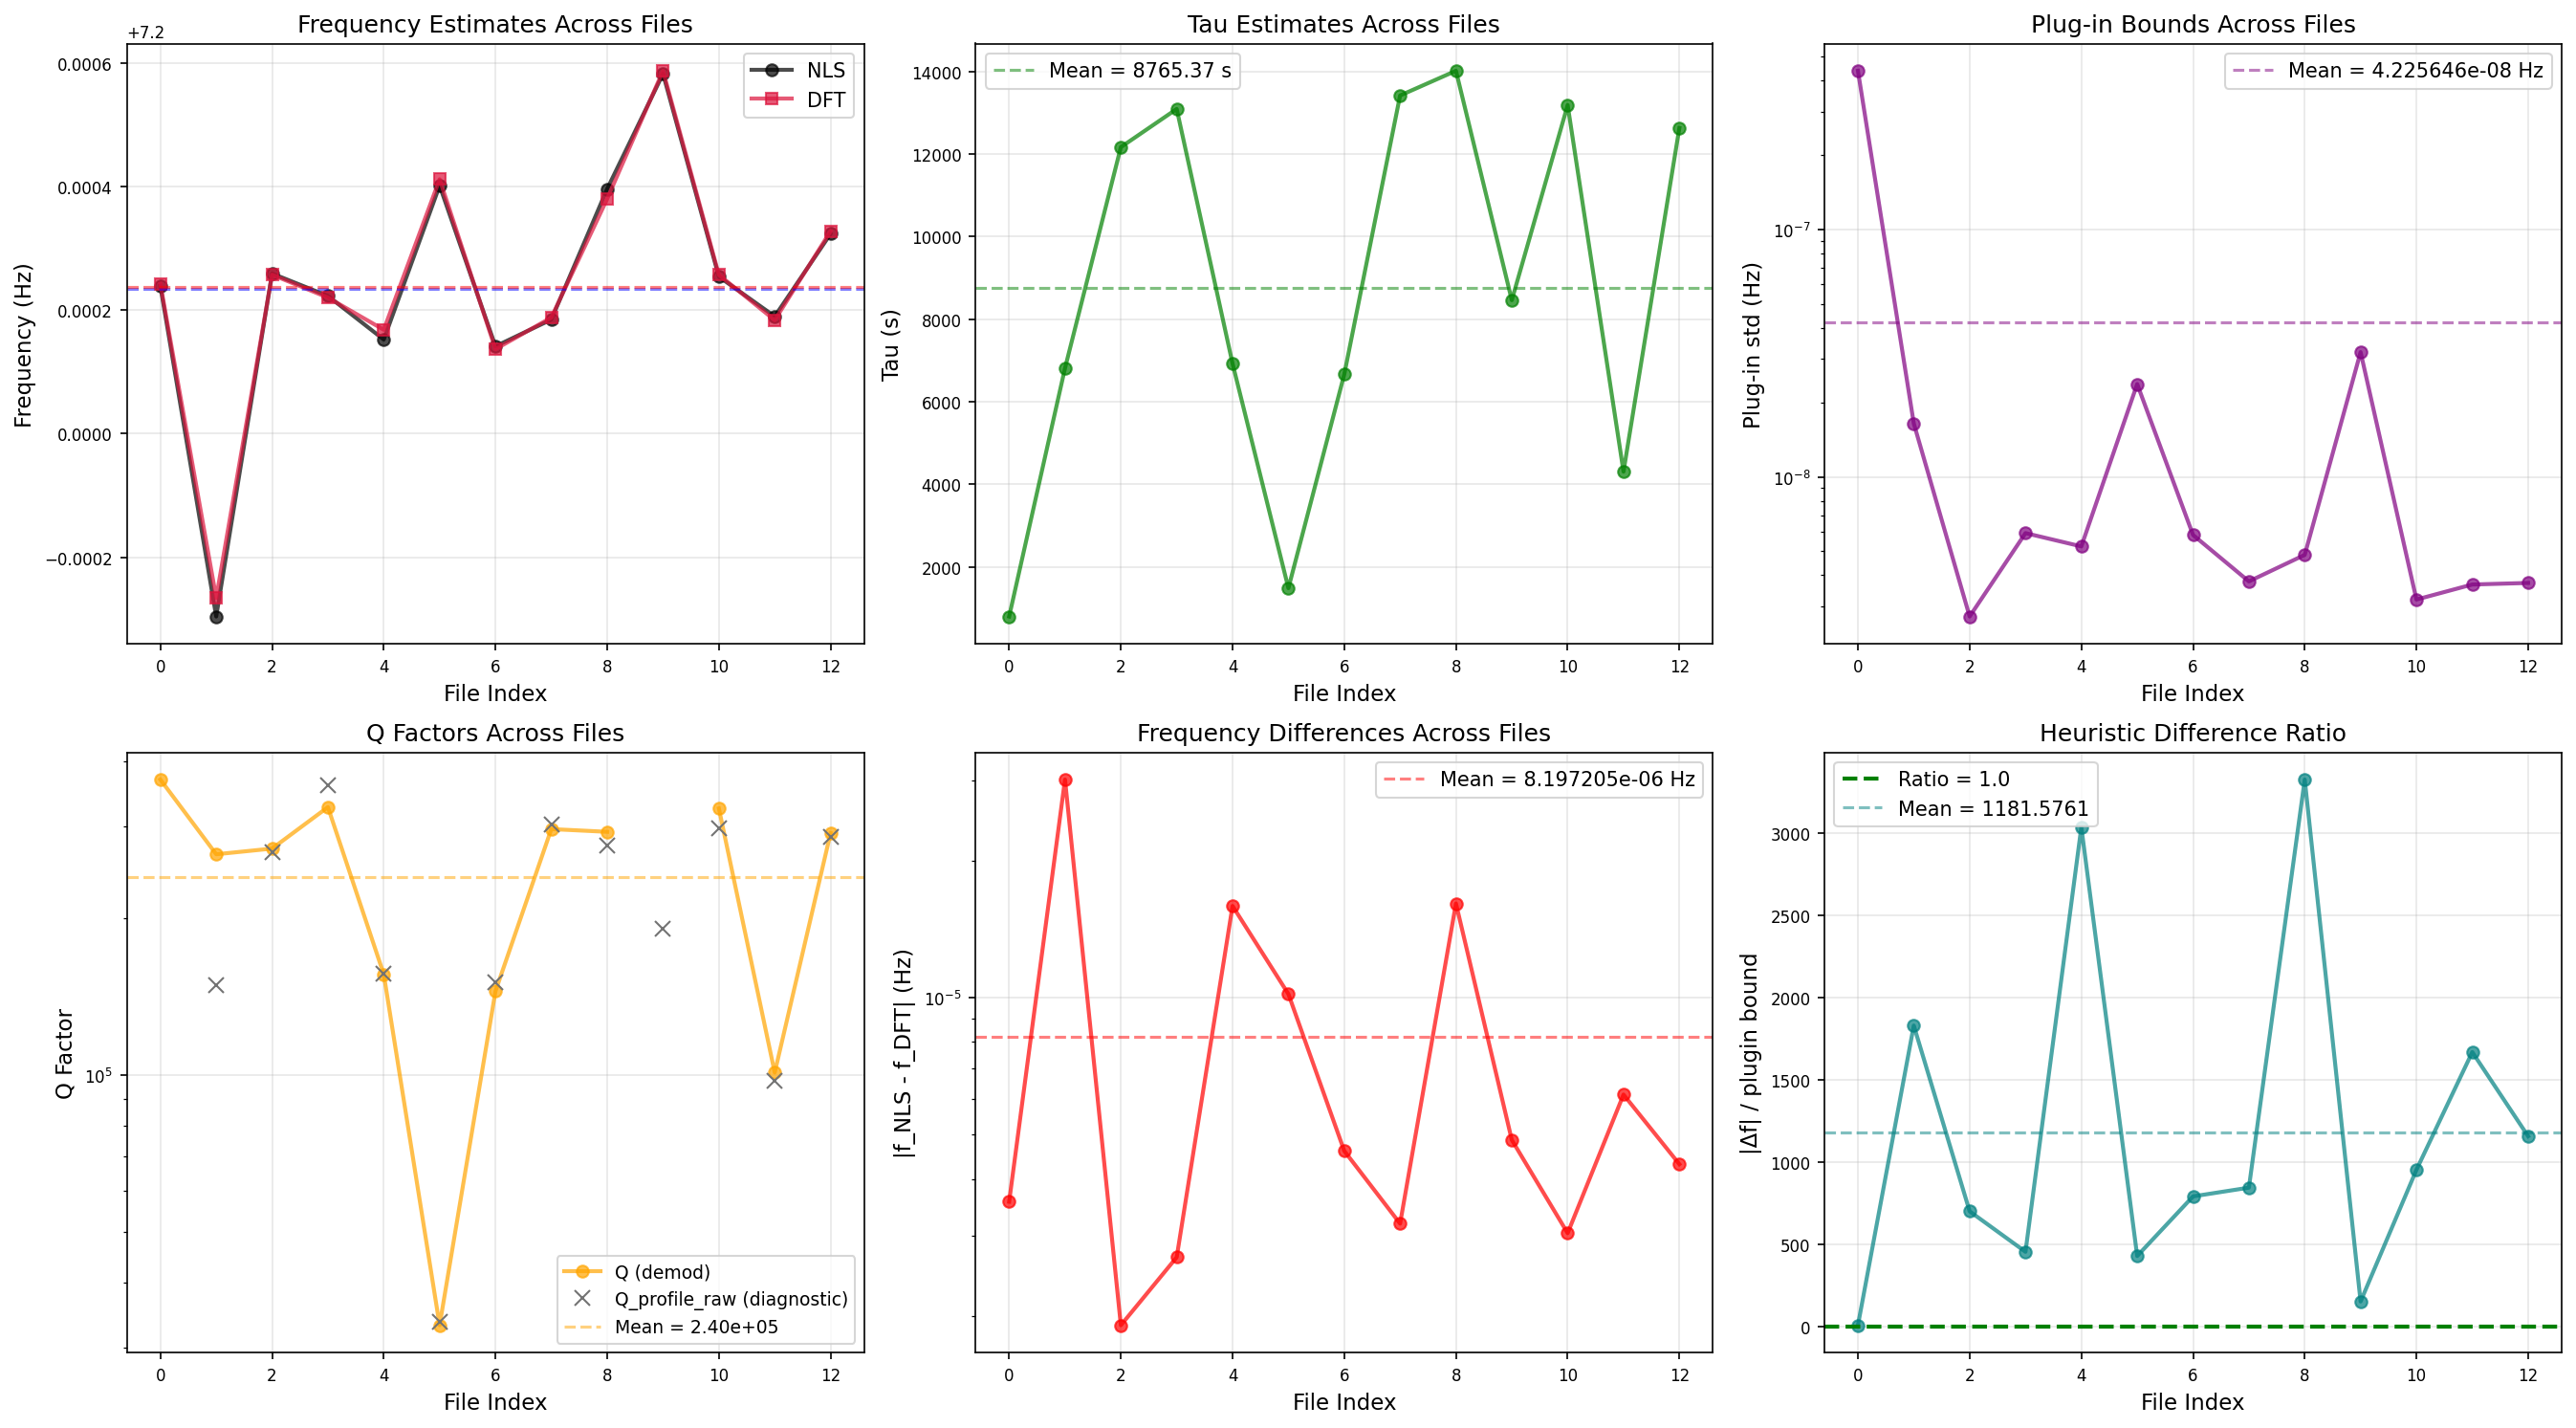


Analysis Complete!


In [24]:
# Create a comprehensive summary visualization
if len(results) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    f_nls_all = np.array([r["f_nls"] for r in results])
    f_dft_all = np.array([r["f_dft"] for r in results])
    tau_all = np.array([r["tau_est"] for r in results])
    plugin_all = np.array([r["plugin_crlb_std_f"] for r in results])

    # 1. Frequency estimates over file index
    ax = axes[0, 0]
    indices = np.arange(len(results))
    ax.plot(indices, f_nls_all, "o-", label="NLS", alpha=0.7, linewidth=2, markersize=6)
    ax.plot(indices, f_dft_all, "s-", label="DFT", alpha=0.7, linewidth=2, markersize=6)
    ax.axhline(consistency["nls_mean"], color="blue", linestyle="--", alpha=0.5)
    ax.axhline(consistency["dft_mean"], color="red", linestyle="--", alpha=0.5)
    ax.set_xlabel("File Index", fontsize=11)
    ax.set_ylabel("Frequency (Hz)", fontsize=11)
    ax.set_title("Frequency Estimates Across Files", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # 2. Tau estimates
    ax = axes[0, 1]
    ax.plot(indices, tau_all, "o-", color="green", alpha=0.7, linewidth=2, markersize=6)
    ax.axhline(
        np.mean(tau_all),
        color="green",
        linestyle="--",
        alpha=0.5,
        label=f"Mean = {np.mean(tau_all):.2f} s",
    )
    ax.set_xlabel("File Index", fontsize=11)
    ax.set_ylabel("Tau (s)", fontsize=11)
    ax.set_title("Tau Estimates Across Files", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # 3. Plug-in uncertainty values
    ax = axes[0, 2]
    ax.plot(indices, plugin_all, "o-", color="purple", alpha=0.7, linewidth=2, markersize=6)
    ax.axhline(
        np.mean(plugin_all),
        color="purple",
        linestyle="--",
        alpha=0.5,
        label=f"Mean = {np.mean(plugin_all):.6e} Hz",
    )
    ax.set_xlabel("File Index", fontsize=11)
    ax.set_ylabel("Plug-in std (Hz)", fontsize=11)
    ax.set_title("Plug-in Bounds Across Files", fontsize=12)
    ax.set_yscale("log")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # 4. Aggregate Q (demod preference) with the coherent diagnostic for contrast
    if "Q" in results[0]:
        q_all = np.array([r["Q"] if r["Q"] is not None else np.nan for r in results])
        q_profile_raw = np.array(
            [r["Q_profile_raw"] if r["Q_profile_raw"] is not None else np.nan for r in results]
        )
        ax = axes[1, 0]
        ax.plot(indices, q_all, "o-", color="orange", alpha=0.7, linewidth=2, markersize=6,
                label=f"Q ({batch_analyzer.q_preference})")
        ax.plot(indices, q_profile_raw, "x", color="0.45", markersize=8,
                label="Q_profile_raw (diagnostic)")
        ax.axhline(
            q_stats["mean"],
            color="orange",
            linestyle="--",
            alpha=0.5,
            label=f"Mean = {q_stats['mean']:.2e}",
        )
        ax.set_xlabel("File Index", fontsize=11)
        ax.set_ylabel("Q Factor", fontsize=11)
        ax.set_title("Q Factors Across Files", fontsize=12)
        ax.set_yscale("log")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    # 5. Frequency difference vs file index
    ax = axes[1, 1]
    diffs = np.abs(f_nls_all - f_dft_all)
    ax.plot(indices, diffs, "o-", color="red", alpha=0.7, linewidth=2, markersize=6)
    ax.axhline(
        np.mean(diffs),
        color="red",
        linestyle="--",
        alpha=0.5,
        label=f"Mean = {np.mean(diffs):.6e} Hz",
    )
    ax.set_xlabel("File Index", fontsize=11)
    ax.set_ylabel("|f_NLS - f_DFT| (Hz)", fontsize=11)
    ax.set_title("Frequency Differences Across Files", fontsize=12)
    ax.set_yscale("log")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # 6. Heuristic ratio of difference to plug-in bound
    if len(crlb_analysis["valid_ratios"]) > 0:
        ratios = crlb_analysis["ratios"]
        valid_mask = np.isfinite(ratios)
        valid_indices = indices[valid_mask]
        valid_ratios = ratios[valid_mask]
        ax = axes[1, 2]
        ax.plot(
            valid_indices, valid_ratios, "o-", color="teal", alpha=0.7, linewidth=2, markersize=6
        )
        ax.axhline(1.0, color="g", linestyle="--", linewidth=2, label="Ratio = 1.0")
        ax.axhline(
            crlb_analysis["ratio_statistics"]["mean"],
            color="teal",
            linestyle="--",
            alpha=0.5,
            label=f"Mean = {crlb_analysis['ratio_statistics']['mean']:.4f}",
        )
        ax.set_xlabel("File Index", fontsize=11)
        ax.set_ylabel("|Δf| / plugin bound", fontsize=11)
        ax.set_title("Heuristic Difference Ratio", fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 70)
    print("Analysis Complete!")
    print("=" * 70)

## Inference-Based Q Across Realizations

The files analyzed here are different realizations of the same experiment, so Q should be compared as a repeated-measurement inference problem. The finite estimate to compare is `Q_demod` with its block-bootstrap `Q_demod_ci95`: it is measured incoherently from the segment envelope, so slow frequency drift does not bias it, and the driven plateau is subtracted rather than fitted through.

`Q_profile` and `Q_nls_raw` are kept in the table as optimizer diagnostics. They can look extremely precise (relative CI widths of 1e-4) while being biased by factors of 2–4 on drifting records, which is why the pipeline demotes them to non-valid when `coherence_gate_fired` or `envelope_mismatch` applies — a `Q_profile` of `None` with status `warning` is the pipeline refusing to certify a coherent fit, not a failed measurement.

Where a record yields no finite Q at all (`Q_demod_status="plateau_dominated"`, or a cross-estimator disagreement in `Q_selected_reasons`), quote the limit or the diagnostics rather than a number.

In [25]:
if len(results) == 0:
    print("No batch results available. Run the processing cells above first.")
elif "Q_demod_status" not in results[0]:
    print("These results do not include demodulation-Q fields. Re-run the processing cells with the current package version.")
else:
    q_rows = []
    for idx, r in enumerate(results):
        demod_ci = r.get("Q_demod_ci95")
        profile_ci = r.get("Q_profile_ci95")
        q_rows.append(
            {
                "index": idx,
                "filename": Path(r.get("filename", f"record_{idx}")).name,
                "Q_selected": r.get("Q_selected"),
                "Q_selected_source": r.get("Q_selected_source"),
                "Q_selected_regime": r.get("Q_selected_regime"),
                "Q_selected_status": r.get("Q_selected_status"),
                "Q_selected_reasons": ", ".join(r.get("Q_selected_reasons", [])),
                "Q_demod": r.get("Q_demod"),
                "Q_demod_status": r.get("Q_demod_status"),
                "Q_demod_ci95_low": demod_ci[0] if demod_ci is not None else np.nan,
                "Q_demod_ci95_high": demod_ci[1] if demod_ci is not None else np.nan,
                "tau_demod": r.get("tau_demod"),
                "coherence_ratio": r.get("coherence_ratio"),
                "coherence_gate_fired": r.get("coherence_gate_fired"),
                "plateau_detected": r.get("Q_demod_plateau_detected"),
                "drift_mHz": (r.get("Q_demod_drift_hz") or np.nan) * 1e3,
                "Q_profile": r.get("Q_profile"),
                "Q_profile_status": r.get("Q_profile_status"),
                "Q_profile_raw": r.get("Q_profile_raw"),
                "Q_profile_ci95_low": profile_ci[0] if profile_ci is not None else np.nan,
                "Q_profile_ci95_high": profile_ci[1] if profile_ci is not None else np.nan,
                "Q_profile_lower_limit_95": r.get("Q_profile_lower_limit_95"),
                "Q_profile_upper_limit_95": r.get("Q_profile_upper_limit_95"),
                "Q_envelope": r.get("Q_envelope"),
                "Q_nls_raw": r.get("Q_nls_raw"),
            }
        )

    q_compare = pd.DataFrame(q_rows)
    q_compare["demod_to_profile_raw_ratio"] = q_compare["Q_demod"] / q_compare["Q_profile_raw"]

    display(
        q_compare[
            [
                "index",
                "filename",
                "Q_selected",
                "Q_selected_source",
                "Q_selected_status",
                "Q_demod",
                "Q_demod_ci95_low",
                "Q_demod_ci95_high",
                "Q_demod_status",
                "coherence_ratio",
                "coherence_gate_fired",
                "Q_profile",
                "Q_profile_status",
                "Q_profile_raw",
                "demod_to_profile_raw_ratio",
            ]
        ]
    )

    print("Demodulation-Q status counts:")
    print(q_compare["Q_demod_status"].value_counts(dropna=False).to_string())
    print("\nSelected-Q source counts:")
    print(q_compare["Q_selected_source"].value_counts(dropna=False).to_string())
    print("\nProfile-Q status counts (gated coherent diagnostic):")
    print(q_compare["Q_profile_status"].value_counts(dropna=False).to_string())

    def summarize_repeated_q(label, values):
        values = pd.Series(values, dtype="float64").dropna()
        if values.empty:
            print(f"{label}: no finite values")
            return
        cv = values.std(ddof=0) / values.mean() if values.mean() > 0 else np.nan
        print(
            f"{label}: n={len(values)}, mean={values.mean():.3e}, "
            f"std={values.std(ddof=0):.3e}, CV={cv:.3%}"
        )

    print("\nAcross-realization finite-Q summaries:")
    summarize_repeated_q("Demodulation Q (recommended)", q_compare["Q_demod"])
    summarize_repeated_q("Selected Q", q_compare["Q_selected"])
    summarize_repeated_q("Envelope Q (diagnostic)", q_compare["Q_envelope"])
    summarize_repeated_q("Profile finite Q (gated)", q_compare["Q_profile"])
    summarize_repeated_q("Profile raw Q (diagnostic)", q_compare["Q_profile_raw"])
    summarize_repeated_q("NLS raw Q (diagnostic)", q_compare["Q_nls_raw"])

,index,filename,Q_selected,Q_selected_source,Q_selected_status,Q_demod,Q_demod_ci95_low,Q_demod_ci95_high,Q_demod_status,coherence_ratio,coherence_gate_fired,Q_profile,Q_profile_status,Q_profile_raw,demod_to_profile_raw_ratio
0,0,MTS_ringdown_050_laser_out_Test1_20250828_0141...,369479.156568,demod,valid,369479.156568,355047.417917,389068.959075,valid,0.188969,False,NaN,upper_limit,NaN,NaN
1,1,MTS_ringdown_050_laser_out_Test5_20250901_2247...,265591.413440,demod,valid,265591.413440,258220.875110,275145.514871,valid,0.783030,True,NaN,warning,148817.383515,1.784680
2,2,MTSRingdownEighthAttempt_20250904_111201.mat,267656.390366,profile,valid,272342.704738,251969.652116,292267.655692,valid,0.000787,False,267656.390366,valid,267656.390366,1.017509
3,3,MTSRingdownEleventhAttempt_20250907_165500.mat,327091.827846,demod,valid,327091.827846,314899.765376,337928.485278,valid,0.146781,False,360036.438998,valid,360036.438998,0.908496
4,4,MTSRingdownFifthAttempt_20250828_132020 1.mat,156217.660146,demod,valid,156217.660146,153504.907854,159343.117503,valid,0.446807,True,NaN,warning,156622.029663,0.997418
5,5,MTSRingdownFirstAttempt_20250826_163810 1.mat,33150.090677,demod,valid,33150.090677,31893.198018,34616.511063,valid,0.204226,True,NaN,warning,33629.991053,0.985730
6,6,MTSRingdownFourthAttempt_20250828_110040 1.mat,145025.976681,demod,valid,145025.976681,134938.041730,157033.465013,valid,0.226402,True,NaN,warning,150704.053916,0.962323
7,7,MTSRingdownNinthAttempt_20250905_094849.mat,296842.236441,demod,valid,296842.236441,276215.343598,321997.690552,valid,1.025287,True,NaN,warning,303460.077290,0.978192
8,8,MTSRingdownSeventhAttempt_20250903_122800.mat,276045.877230,profile,valid,293282.547645,285010.092503,302077.273800,valid,0.059022,False,276045.877230,valid,276045.877230,1.062441
9,9,MTSRingdownSixthAttempt_20250902_143723.mat,NaN,none,invalid,256926.777010,254945.443636,259263.670510,warning,3.551059,True,NaN,warning,191370.119453,1.342565


Demodulation-Q status counts:
Q_demod_status
valid      12
warning     1

Selected-Q source counts:
Q_selected_source
demod      10
profile     2
none        1

Profile-Q status counts (gated coherent diagnostic):
Q_profile_status
warning        8
valid          4
upper_limit    1

Across-realization finite-Q summaries:
Demodulation Q (recommended): n=13, mean=2.411e+05, std=9.624e+04, CV=39.921%
Selected Q: n=12, mean=2.379e+05, std=9.928e+04, CV=41.725%
Envelope Q (diagnostic): n=13, mean=2.399e+05, std=9.936e+04, CV=41.411%
Profile finite Q (gated): n=4, mean=2.503e+05, std=9.535e+04, CV=38.095%
Profile raw Q (diagnostic): n=12, mean=2.142e+05, std=9.426e+04, CV=44.000%
NLS raw Q (diagnostic): n=13, mean=2.372e+05, std=1.112e+05, CV=46.887%


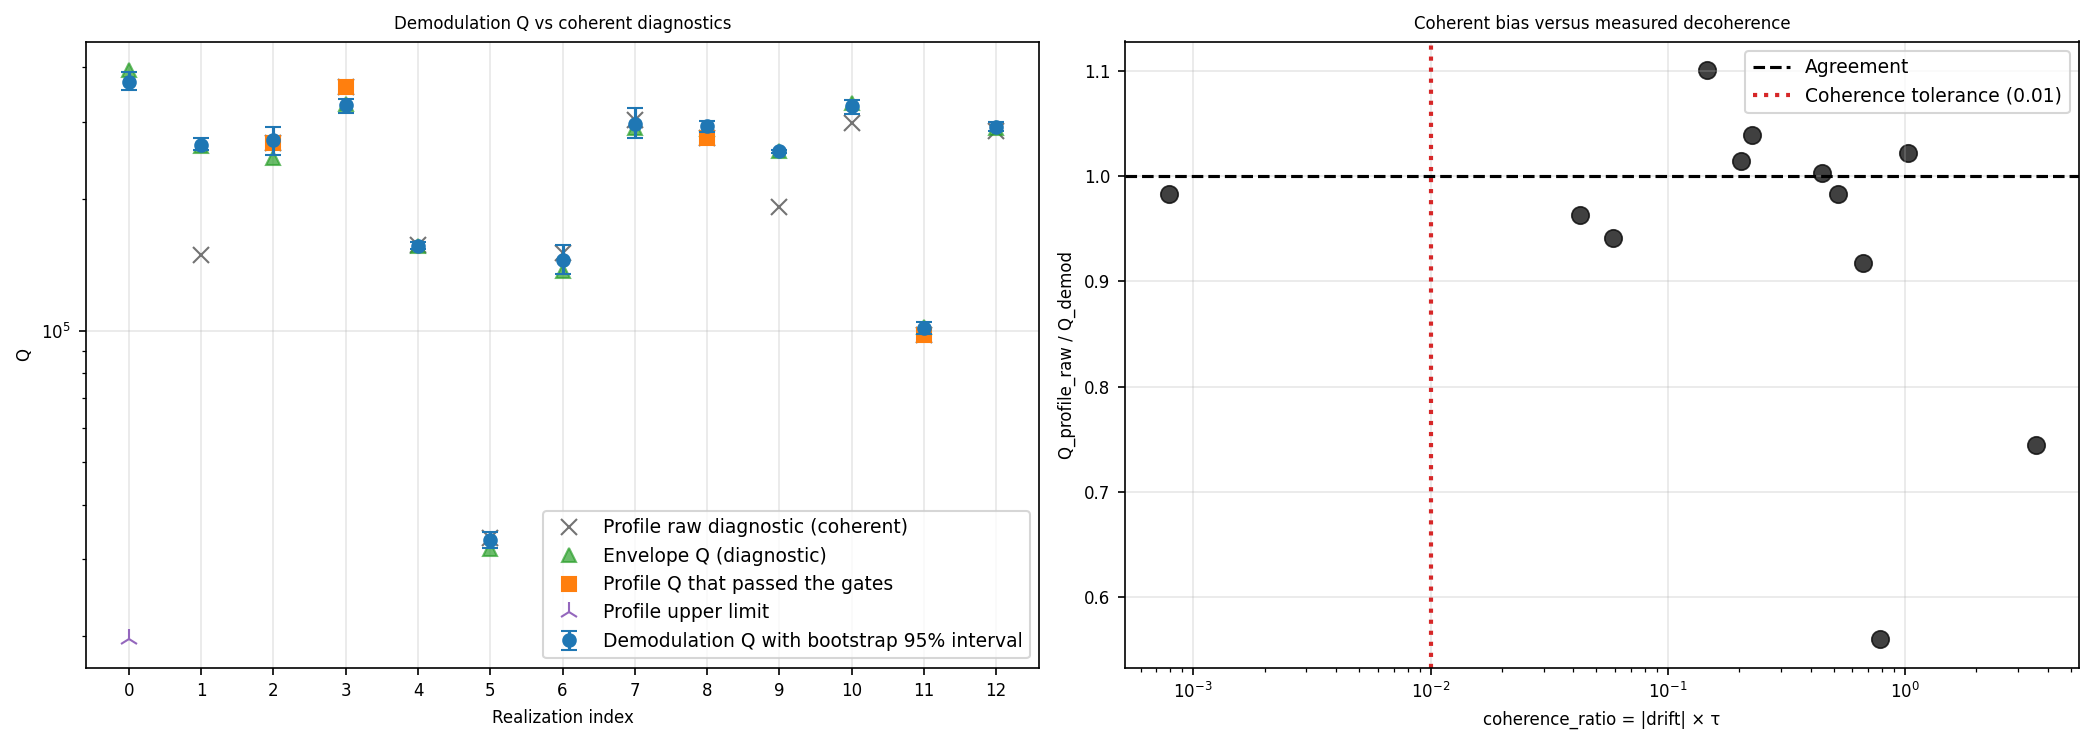

In [26]:
if "q_compare" not in globals() or q_compare.empty:
    print("No Q comparison table available. Run the previous cell first.")
else:
    finite_demod = q_compare["Q_demod"].notna()
    finite_profile = q_compare["Q_profile"].notna()
    finite_profile_raw = q_compare["Q_profile_raw"].notna()
    finite_envelope = q_compare["Q_envelope"].notna()
    has_limits = q_compare["Q_profile_lower_limit_95"].notna() | q_compare["Q_profile_upper_limit_95"].notna()

    if not finite_demod.any() and not finite_profile_raw.any() and not has_limits.any():
        print("No finite Q values or profile limits to plot.")
    else:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ax = axes[0]

        if finite_profile_raw.any():
            ax.plot(
                q_compare.loc[finite_profile_raw, "index"],
                q_compare.loc[finite_profile_raw, "Q_profile_raw"],
                "x",
                color="0.45",
                markersize=8,
                label="Profile raw diagnostic (coherent)",
            )

        if finite_envelope.any():
            ax.plot(
                q_compare.loc[finite_envelope, "index"],
                q_compare.loc[finite_envelope, "Q_envelope"],
                "^",
                color="tab:green",
                markersize=7,
                alpha=0.7,
                label="Envelope Q (diagnostic)",
            )

        if finite_profile.any():
            ax.plot(
                q_compare.loc[finite_profile, "index"],
                q_compare.loc[finite_profile, "Q_profile"],
                "s",
                color="tab:orange",
                markersize=7,
                label="Profile Q that passed the gates",
            )

        if finite_demod.any():
            yerr_low = q_compare.loc[finite_demod, "Q_demod"] - q_compare.loc[finite_demod, "Q_demod_ci95_low"]
            yerr_high = q_compare.loc[finite_demod, "Q_demod_ci95_high"] - q_compare.loc[finite_demod, "Q_demod"]
            ax.errorbar(
                q_compare.loc[finite_demod, "index"],
                q_compare.loc[finite_demod, "Q_demod"],
                yerr=[yerr_low.fillna(0.0), yerr_high.fillna(0.0)],
                fmt="o",
                color="tab:blue",
                ecolor="tab:blue",
                capsize=4,
                markersize=6,
                label="Demodulation Q with bootstrap 95% interval",
            )

        lower_limit = q_compare["Q_profile_lower_limit_95"].notna()
        if lower_limit.any():
            ax.plot(
                q_compare.loc[lower_limit, "index"],
                q_compare.loc[lower_limit, "Q_profile_lower_limit_95"],
                "1",
                color="tab:red",
                markersize=10,
                label="Profile lower limit",
            )

        upper_limit = q_compare["Q_profile_upper_limit_95"].notna()
        if upper_limit.any():
            ax.plot(
                q_compare.loc[upper_limit, "index"],
                q_compare.loc[upper_limit, "Q_profile_upper_limit_95"],
                "2",
                color="tab:purple",
                markersize=10,
                label="Profile upper limit",
            )

        ax.set_xlabel("Realization index")
        ax.set_ylabel("Q")
        ax.set_title("Demodulation Q vs coherent diagnostics")
        ax.set_xticks(q_compare["index"])
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

        # How far the coherent fit departs from the drift-immune value, as a
        # function of the measured decoherence.
        ax = axes[1]
        both = finite_demod & finite_profile_raw & q_compare["coherence_ratio"].notna()
        if both.any():
            x = q_compare.loc[both, "coherence_ratio"]
            y = q_compare.loc[both, "Q_profile_raw"] / q_compare.loc[both, "Q_demod"]
            ax.scatter(x, y, s=70, alpha=0.75, edgecolors="black", linewidths=0.8)
            ax.axhline(1.0, color="k", linestyle="--", linewidth=1.5, label="Agreement")
            ax.axvline(
                0.01,
                color="tab:red",
                linestyle=":",
                linewidth=2,
                label="Coherence tolerance (0.01)",
            )
            ax.set_xscale("log")
            ax.set_xlabel("coherence_ratio = |drift| × τ")
            ax.set_ylabel("Q_profile_raw / Q_demod")
            ax.set_title("Coherent bias versus measured decoherence")
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=9)
        else:
            ax.axis("off")
            ax.text(
                0.5,
                0.5,
                "No records have both a finite demodulation Q and a finite raw profile Q.",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )

        plt.tight_layout()
        plt.show()

## Amplitude-Resolved Q Across Realizations

If the local Q varies with amplitude, records that differ only in release amplitude or window
length will disagree on Q even when the resonator is unchanged — a single-exponential Q is then a
window-dependent average, not a property of the device. `Q_demod_vs_amplitude` exposes the local Q
per amplitude band for every record, so the realizations can be compared band by band; a common
Q(A) trend across records is physics, while vertical scatter at matched amplitude is measurement
spread. Read bands with few segments (`n_segments` in the table) with caution: a band covering only
a handful of segments has a poorly constrained slope, and near the plateau cutoff it can be
dominated by the driven floor.

,index,filename,amplitude_mid,amplitude_low,amplitude_high,n_segments,tau,Q
0,0,MTS_ringdown_050_laser_out_Test1_20250828_0141...,458.612704,324.288153,648.576305,23,14355.621885,3.247054e+05
1,0,MTS_ringdown_050_laser_out_Test1_20250828_0141...,229.306352,162.144076,324.288153,26,15735.306570,3.559171e+05
2,0,MTS_ringdown_050_laser_out_Test1_20250828_0141...,114.653176,81.072038,162.144076,23,15639.932272,3.537573e+05
3,0,MTS_ringdown_050_laser_out_Test1_20250828_0141...,72.968144,65.674309,81.072038,23,59587.385731,1.347787e+06
4,1,MTS_ringdown_050_laser_out_Test5_20250901_2247...,361.397058,255.546310,511.092620,19,13917.963333,3.148036e+05
5,1,MTS_ringdown_050_laser_out_Test5_20250901_2247...,180.698529,127.773155,255.546310,18,13879.233550,3.139312e+05
6,1,MTS_ringdown_050_laser_out_Test5_20250901_2247...,90.349264,63.886578,127.773155,14,17823.370942,4.031426e+05
7,1,MTS_ringdown_050_laser_out_Test5_20250901_2247...,45.174632,31.943289,63.886578,23,17531.482058,3.965389e+05
8,2,MTSRingdownEighthAttempt_20250904_111201.mat,200.844094,142.018221,284.036441,64,14116.761839,3.193250e+05
9,2,MTSRingdownEighthAttempt_20250904_111201.mat,100.422047,71.009110,142.018221,26,6682.547595,1.511609e+05


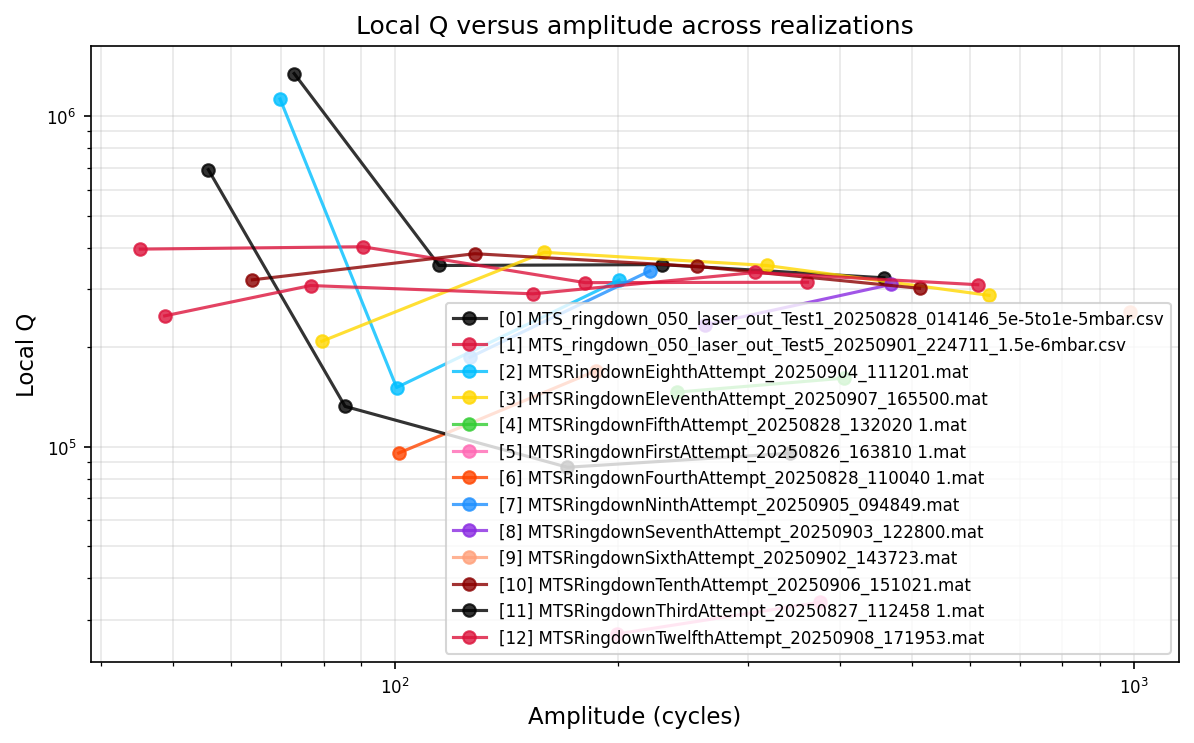

Within-record local-Q spread (max/min across amplitude bands):
  [0] MTS_ringdown_050_laser_out_Test1_20250828_014146_5e-5to1e-5mbar.csv: 4.15×
  [1] MTS_ringdown_050_laser_out_Test5_20250901_224711_1.5e-6mbar.csv: 1.28×
  [2] MTSRingdownEighthAttempt_20250904_111201.mat: 7.47×
  [3] MTSRingdownEleventhAttempt_20250907_165500.mat: 1.86×
  [4] MTSRingdownFifthAttempt_20250828_132020 1.mat: 1.10×
  [5] MTSRingdownFirstAttempt_20250826_163810 1.mat: 1.25×
  [6] MTSRingdownFourthAttempt_20250828_110040 1.mat: 1.77×
  [7] MTSRingdownNinthAttempt_20250905_094849.mat: 1.82×
  [8] MTSRingdownSeventhAttempt_20250903_122800.mat: 1.33×
  [9] MTSRingdownSixthAttempt_20250902_143723.mat: 1.00×
  [10] MTSRingdownTenthAttempt_20250906_151021.mat: 1.27×
  [11] MTSRingdownThirdAttempt_20250827_112458 1.mat: 7.95×
  [12] MTSRingdownTwelfthAttempt_20250908_171953.mat: 1.35×


In [27]:
if len(results) == 0:
    print("No batch results available. Run the processing cells above first.")
else:
    band_rows = []
    for idx, r in enumerate(results):
        for band in r.get("Q_demod_vs_amplitude", []):
            band_rows.append(
                {
                    "index": idx,
                    "filename": Path(r["filename"]).name,
                    "amplitude_mid": band.amplitude_mid,
                    "amplitude_low": band.amplitude_low,
                    "amplitude_high": band.amplitude_high,
                    "n_segments": band.n_segments,
                    "tau": band.tau,
                    "Q": band.Q,
                }
            )

    if not band_rows:
        print("No amplitude-resolved Q bands available (records need several decay segments per band).")
    else:
        bands_df = pd.DataFrame(band_rows)
        display(bands_df)

        fig, ax = plt.subplots(figsize=(8, 5))
        for idx, group in bands_df.groupby("index"):
            ax.loglog(
                group["amplitude_mid"],
                group["Q"],
                "o-",
                alpha=0.8,
                markersize=6,
                label=f"[{idx}] {group['filename'].iloc[0]}",
            )
        ax.set_xlabel("Amplitude (cycles)", fontsize=11)
        ax.set_ylabel("Local Q", fontsize=11)
        ax.set_title("Local Q versus amplitude across realizations", fontsize=12)
        ax.grid(True, alpha=0.3, which="both")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

        spread = bands_df.groupby("index")["Q"].agg(lambda q: q.max() / q.min())
        print("Within-record local-Q spread (max/min across amplitude bands):")
        for idx, value in spread.items():
            print(f"  [{idx}] {bands_df.loc[bands_df['index'] == idx, 'filename'].iloc[0]}: {value:.2f}×")